# Bending Spoons Technical Task - Full Notebook
**Ad Performance Dataset: analysis by Yung-Hsuan Wu**

This full notebook contains the data analysis and visualization code I wrote for Bending Spoons technical task, based on Bending Spoons' provided Ad Performance Dataset.

It accompanies the Google Slide deck shared together with the submission form, yet it includes more information than the code and graphs actually used in the presentation.

For the presentation code, please see ```yhw-task-submission-presentation.ipynb```.

This notebook is meant for a technical analyst to read, and the Google Slide deck is written with a general non-technical audience in mind.

# Introduction

## Dataset information

To ensure consistency, the following information was copied and emphasized with bold fonts from the original dataset description, which can be found in the ```ad_performance``` folder.

Ad Performance Dataset is a time-series data from a Facebook app-install campaign promoting a single iOS app in **Brazil**, running **October 7, 2025 to December 31, 2025**. The app was free; monetization came from **in-app purchases** and **in-app ads**. The campaign used **one creative, broad audience**, and **iOS Facebook app placements only**. A **daily budget cap of $90** was set throughout.

In the **Ad Data** sheet, there are the following columns:
* Date
* Ad spend (USD) — Amount spent that day (daily budget capped at $90).
* CPM (USD) — Cost per 1,000 impressions.
* CTR (%) — Click-through rate: share of impressions that generated a click/tap.
* Paid downloads (count) — Installs attributed to the ad.
* CPI (USD) — Cost per install: Ad spend ÷ Paid downloads.
* ARPD on paid downloads (USD) — Average revenue per ad-attributed install.
* APPD on paid downloads (USD) — Average profit per ad-attributed install.

Note: Revenue can be derived from both in-app purchases and in-app ads; i.e., the trend ARPD might be explained by two different sources of revenue.

In the **Downloads timeseries** sheet, there are the following columns:
* Date
* Total downloads (count) — All installs, per day.

**Granularity, units, and attribution**
* Granularity: Daily rows spanning 2025-10-07 to 2025-12-31.
* Currency: USD.
* Attribution: “Paid downloads,” ARPD, and APPD refer only to users who installed after engaging with the Facebook ad (iOS placement).
* Platform & market scope: iOS only; Brazil only

## Assumptions
About the dataset

1. This dataset is exported from Meta Ads Manager: I used Meta Ads Manager documentation to assist my interpretation of the dataset. While I aim to draw reasonable conclusions that should be applicable in case this dataset was exported from other third-party tools, some results might need minor adjustements or re-interpretation.

> * How did I make this assumption?
>   * The data description said this timeseries dataset is from a Facebook App-Install campaign, and the performance metric names mirror Meta Ads Manager's metrics.
> * Why make this assumption?
>   * Knowing where the dataset comes from helps disambiguiate metric definitions and calculations, which are key to providing correct analyses.
> * When does this assumption break?
>   * If the marketing team, the likely provider of this dataset, explicitly gives another source for this dataset, this assumption will break.

2. Revenue calculation is cohort-based, not activity-date-based: I assume the revenue calculation of ARPD (and consequently profit calculation in APPD) is based on the cohort of paid download users of the same day. For example, the ARPD of 7 October is calculated as: all revenue generated by every paid download of that day ÷ the number of paid downloads. If a user downloaded the app on 7 October but only made a purchase on 9 October, the purchase will count towards the revenue calculation of 7 October, not 9 October. 

> * How did I make this assumption?
>   * I verified the following computationally:
>     * For every given day, CPI = Ad spend (of that day) ÷ the number of paid downloads (of that day).
>     * For every given day, CPI = ARPD - APPD, suggesting to me that ARPD, APPD, and CPI all use the same denominator, which is the number of paid downloads of that day.
>   * This is also [how Meta's Ads Manager calculates average revenue per user (ARPU)](https://developers.facebook.com/docs/app-ads/measuring/measuring-installs-and-in-app-conversions/), the closest metric to ARPD, by default.
> * Why make this assumption?
>   * Getting to the bottom of how revenue is calculated helps me understand the real behavior of revenue and the core business problem, i.e., whether and how this ad campaign is generating revenue, and how return on ad spend (ROAS) should be analyzed. 
> * When does this assumption break?
>   * If revenue is calculated by activity-date, i.e., whenever a purchase or ad-revenue actually occurred, then the revenue is essentially accumulative across cohorts. Cohorts of 7 October and 8 October might all contribute to revenue of 9 October; this would mean that the total revenue for each day should be non-decreasing. However, this doesn't align with the data I saw, and the verification step I took told me otherwise. 

3. Revenue calculation is based on a fixed date range: I assume revenue calculation for a fixed cohort is reported over a fixed-date range for all cohorts, meaning that each and every cohort has the exact same maturity level in terms of revenue generation. For example, the ARPD figures reported for 7 October and 9 October are based on revenue generated by those cohorts respectively over the same number of days. 

> * How did I make this assumption?
>   * Based on [Meta Ads Manager's documentation](https://developers.facebook.com/docs/app-ads/measuring/measuring-installs-and-in-app-conversions/), the platform reports 1-day, 3-day, and other fixed-day views for ARPU. Assuming that this dataset is exported from Meta Ads Manager, it's reasonable to conclude that ARPD and APPD are also reported by a fixed-date range.
> * Why make this assumption?
>   * This assumption helps us eliminate a confounding variable, which is cohort maturity. Without this assumption, each cohort may have different durations of revenue generation, where earlier cohorts would have had more time to spend money than later cohorts by virtue of having been using the app for longer (i.e., more mature). With fixed-date range revenue calculations, I can fairly compare ARPD across cohorts as each cohort will be at the same level of maturity.
> * When does this assumption break?
>   * If the marketing team, the likely provider of this dataset, explicitly says otherwise, this assumption will break.

# Technical setup
In this section, I prepared commands that would help set up the technical environment for running this notebook. 

In [1]:
# Before running the notebook, please uncomment the following to install all dependencies:
# !pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Data preparation and structure
In this section, I demonstrate how I loaded, inspected, and cleaned the data before the analysis. Run it all at once to get the finalized data for analysis. 

1. Inspect data (read, shape, and types)
2. Beautify column names for better indexing
3. Check for NaN/null/duplicate values: **no missing values nor duplicates found!**
4. Segment data by relevant dates
5. Join relevant parts of ad and download data
6. Verify metrics to ensure data consistency
7. Expand dataset with missing yet potentially informative metrics (e.g., absolutes)

In [3]:
# 1. Inspect data and check for data types and shape

xlsx = pd.ExcelFile("ad_performance/Ad Performance Dataset.xlsx")
ad_df = pd.read_excel(xlsx, "Ad Data")
download_df = pd.read_excel(xlsx, "Downloads timeseries")

print(f"Ad data has shape {ad_df.shape}")
print(f"First five rows of Ad data:\n{ad_df.head()}")
print(f"Data types of each column in Ad data:\n{ad_df.dtypes}")

print(f"Download data has shape: {download_df.shape}")
print(f"First five rows of Downloads data:\n{download_df.head()}")
print(f"Data types of each column in Download data:\n{download_df.dtypes}")

Ad data has shape (86, 8)
First five rows of Ad data:
        Date  Ad spend   CPM     CTR  Paid downloads    CPI  \
0 2025-10-07        36  0.91  0.0480            1363  0.026   
1 2025-10-08        90  0.90  0.0449            3123  0.029   
2 2025-10-09        90  1.04  0.0460            2787  0.032   
3 2025-10-10        87  1.01  0.0433            2500  0.035   
4 2025-10-11        90  0.92  0.0401            2583  0.035   

   ARPD (on paid downloads)  APPD (on paid downloads)  
0                     0.084                     0.058  
1                     0.083                     0.054  
2                     0.063                     0.031  
3                     0.067                     0.032  
4                     0.081                     0.046  
Data types of each column in Ad data:
Date                        datetime64[us]
Ad spend                             int64
CPM                                float64
CTR                                float64
Paid downloads       

In [4]:
# 2. Beautify column names for exploration
ad_columns_rename = {
  "Date": "date",
  "Ad spend": "ad_spend",
  "CPM": "cpm",
  "CTR": "ctr",
  "Paid downloads": "paid_downloads",
  "CPI": "cpi",
  "ARPD (on paid downloads)": "arpd",
  "APPD (on paid downloads)": "appd"
}

download_df_rename = {
  "Date": "date",
  "Total downloads": "total_downloads"
}

ad_df = ad_df.rename(columns=ad_columns_rename).copy()
download_df = download_df.rename(columns=download_df_rename).copy()

print(f"ad_df column names now:\n{ad_df.columns}")
print(f"download_df column names now:\n{download_df.columns}")

ad_df column names now:
Index(['date', 'ad_spend', 'cpm', 'ctr', 'paid_downloads', 'cpi', 'arpd',
       'appd'],
      dtype='str')
download_df column names now:
Index(['date', 'total_downloads'], dtype='str')


In [5]:
# 3. Check for NaN values and duplicates
print(f"Missing values per column in ad_df:\n{ad_df.isna().sum()}")
print(f"Missing values per column in download_df:\n{download_df.isna().sum()}")
print(f"Duplicate dates in ad_df: {ad_df.date.duplicated().sum()}")
print(f"Duplicate dates in download_df: {download_df.date.duplicated().sum()}")

Missing values per column in ad_df:
date              0
ad_spend          0
cpm               0
ctr               0
paid_downloads    0
cpi               0
arpd              0
appd              0
dtype: int64
Missing values per column in download_df:
date               0
total_downloads    0
dtype: int64
Duplicate dates in ad_df: 0
Duplicate dates in download_df: 0


In [6]:
# 4. Segment data for usage
# Verify date ranges of the data
ad_date_range = [ad_df.date.dt.date.min(), ad_df.date.dt.date.max()]
print(f"ad_df ranges from {str(ad_date_range[0])} to {str(ad_date_range[1])}")

download_date_range = [download_df.date.dt.date.min(), download_df.date.dt.date.max()]
print(f"download_df ranges from {str(download_date_range[0])} to {str(download_date_range[1])}")

ad_df ranges from 2025-10-07 to 2025-12-31
download_df ranges from 2025-08-01 to 2025-12-31


In [7]:
# Since the app-install campaign only ran from October 7, 2025 to December 31, 2025, I sliced the download df into pre- and post-promotion campaign
promo_st = pd.to_datetime(ad_date_range[0])

prepromo_download_df = download_df[download_df.date < promo_st]
postpromo_download_df = download_df[download_df.date >= promo_st]

print(f"prepromo_download_df ranges from {str(prepromo_download_df.date.dt.date.min())} to {str(prepromo_download_df.date.dt.date.max())}")
print(f"prepromo_download_df has {prepromo_download_df.shape[0]} rows")
print(f"postpromo_download_df ranges from {str(postpromo_download_df.date.dt.date.min())} to {str(postpromo_download_df.date.dt.date.max())}")
print(f"postpromo_download_df has {postpromo_download_df.shape[0]} rows")

# I also set date to be index as all dfs are timeseries data
ad_df = ad_df.set_index("date").copy()
download_df = download_df.set_index("date").copy()
prepromo_download_df = prepromo_download_df.set_index("date").copy()
postpromo_download_df = postpromo_download_df.set_index("date").copy()

prepromo_download_df ranges from 2025-08-01 to 2025-10-06
prepromo_download_df has 67 rows
postpromo_download_df ranges from 2025-10-07 to 2025-12-31
postpromo_download_df has 86 rows


In [8]:
# 5. Join relevant parts of ad and download data
# I joined postpromo_download_df and ad_data together, as their date range should now match.
promo_df = pd.merge(ad_df, postpromo_download_df, right_index=True, left_index=True)
promo_df

,ad_spend,cpm,ctr,paid_downloads,cpi,arpd,appd,total_downloads
date,,,,,,,,
2025-10-07,36,0.91,0.0480,1363,0.026,0.084,0.058,3154
2025-10-08,90,0.90,0.0449,3123,0.029,0.083,0.054,4211
2025-10-09,90,1.04,0.0460,2787,0.032,0.063,0.031,4861
2025-10-10,87,1.01,0.0433,2500,0.035,0.067,0.032,4662
2025-10-11,90,0.92,0.0401,2583,0.035,0.081,0.046,4408
...,...,...,...,...,...,...,...,...
2025-12-27,90,1.21,0.0271,932,0.097,0.049,-0.048,2071
2025-12-28,90,1.22,0.0290,1014,0.089,0.085,-0.004,2623
2025-12-29,90,1.13,0.0274,1063,0.085,0.080,-0.005,2195


In [9]:
# Double check if any values are missing
promo_df.isna().sum()

ad_spend           0
cpm                0
ctr                0
paid_downloads     0
cpi                0
arpd               0
appd               0
total_downloads    0
dtype: int64

In [10]:
# 6. Verify metrics to ensure data consistency
# Some metrics might contain false values based on incorrect calculations; specifically, to verify assumption 2, I checked how CPI and APPD were calculated.

# Verify CPI = ad_spend / paid_downloads
cpi_test = promo_df["ad_spend"] / promo_df["paid_downloads"]
if promo_df["cpi"].equals(cpi_test.round(3)):
  print(f"CPI verified: CPI = Ad spend (of that day) ÷ Paid downloads (of that day)")
else:
  print(f"CPI verification failed.")

# Verify APPD = ARPD - CPI
appd_test = promo_df["arpd"] - promo_df["cpi"]
if promo_df["appd"].equals(appd_test.round(3)):
  print(f"APPD verified: APPD (of that day) = ARPD (of that day) - CPI (of that day)")
else:
  print(f"APPD verification failed.")

# This shows that ARPD, APPD, and CPI should be using the same denominator: paid downloads of a given day.
# This further implicates that the revenue in ARPD is calculated on a cohort-basis (the cohort is the paid downloads of that day).

CPI verified: CPI = Ad spend (of that day) ÷ Paid downloads (of that day)
APPD verified: APPD (of that day) = ARPD (of that day) - CPI (of that day)


In [11]:
# 7. Expand the dataset with key metrics
# Total values could reveal information missing from averages or percentages

# Introduce total revenue on paid downloads (trpd) = arpd x paid_downloads
promo_df["trpd"] = promo_df["arpd"] * promo_df["paid_downloads"]

# Introduce total profit on paid downloads (tppd) = appd x paid_downloads
promo_df["tppd"] = promo_df["appd"] * promo_df["paid_downloads"]

# Introduce total impressions = ad_spend x 1000 / cpm
promo_df["total_impressions"] = promo_df["ad_spend"] * 1000 / promo_df["cpm"]

if promo_df.total_impressions.apply(float.is_integer).all():
  promo_df["total_impressions"] = promo_df["total_impressions"].round()
  print(f"Impression counts are whole numbers.")
else:
  print(f"Impression counts are not whole numbers.")

# Introduce total clicks = total_impressions x ctr
promo_df["total_clicks"] = promo_df["total_impressions"] * promo_df["ctr"]

if promo_df.total_clicks.apply(float.is_integer).all():
  promo_df["total_clicks"] = promo_df["total_clicks"].round()
  print(f"Click counts are whole numbers.")
else:
  print(f"Click counts are not whole numbers.")

# Introduce non-paid downloads = total_downloads - paid_downloads
promo_df["nonpaid_downloads"] = promo_df["total_downloads"] - promo_df["paid_downloads"]

# Introduce click to install conversion rate (CIR)
promo_df["cir"] = promo_df["paid_downloads"] / promo_df["total_clicks"]

# Introduce return on ad spend (ROAS) = trpd / ad_spend (i.e., for each dollar spent on ads, how many dollars of revenue are generated)
promo_df["roas"] = promo_df["trpd"] / promo_df["ad_spend"]

promo_df.head()

Impression counts are not whole numbers.
Click counts are not whole numbers.


,ad_spend,cpm,ctr,paid_downloads,cpi,arpd,appd,total_downloads,trpd,tppd,total_impressions,total_clicks,nonpaid_downloads,cir,roas
date,,,,,,,,,,,,,,,
2025-10-07,36,0.91,0.0480,1363,0.026,0.084,0.058,3154,114.492,79.054,39560.439560,1898.901099,1791,0.717784,3.180333
2025-10-08,90,0.90,0.0449,3123,0.029,0.083,0.054,4211,259.209,168.642,100000.000000,4490.000000,1088,0.695546,2.880100
2025-10-09,90,1.04,0.0460,2787,0.032,0.063,0.031,4861,175.581,86.397,86538.461538,3980.769231,2074,0.700116,1.950900
2025-10-10,87,1.01,0.0433,2500,0.035,0.067,0.032,4662,167.500,80.000,86138.613861,3729.801980,2162,0.670277,1.925287
2025-10-11,90,0.92,0.0401,2583,0.035,0.081,0.046,4408,209.223,118.818,97826.086957,3922.826087,1825,0.658454,2.324700


In [12]:
# Double check if any values are missing
promo_df.isna().sum()

ad_spend             0
cpm                  0
ctr                  0
paid_downloads       0
cpi                  0
arpd                 0
appd                 0
total_downloads      0
trpd                 0
tppd                 0
total_impressions    0
total_clicks         0
nonpaid_downloads    0
cir                  0
roas                 0
dtype: int64

# Analysis and visualization
In this section, I demonstrate some fundamental statistics and underlying dynamics of key metrics. It shows more of the analysis process, so not everything made it into the presentation.

For those that did, I marked the cell with comments starting with # \[Presentation].

1. Get summary statistics (mean, median, mode, std, 25% QT, 75% QT) to gain a basic sense of the data.
2. Visualize trend to gain a basic sense of the data.
3. Performance evaluation
  * a. Campaign effects on downloads
  * b. Campaign profitability
4. Problem: Declining revenue
  * a. Hypotheses 1: *“Paid download users were spending less”*
  * b. Hypotheses 2: *“There were less paid downloads.”*
5. Additional analyses


## 1. Summary statistics

In [13]:
# Statistics of prepromo_download_df
print(f"Summary statistics of prepromo_download_df:\n{prepromo_download_df.describe()}")

# Statistics of promo_df
print(f"Summary statistics of promo_df:")
promo_df.describe()

Summary statistics of prepromo_download_df:
       total_downloads
count        67.000000
mean         12.626866
std           6.371898
min           2.000000
25%           7.500000
50%          13.000000
75%          16.500000
max          28.000000
Summary statistics of promo_df:


,ad_spend,cpm,ctr,paid_downloads,cpi,arpd,appd,total_downloads,trpd,tppd,total_impressions,total_clicks,nonpaid_downloads,cir,roas
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,87.941860,1.227907,0.034031,1412.383721,0.067826,0.090465,0.022640,2267.511628,126.423709,38.487372,73985.117881,2490.244293,855.127907,0.557284,1.459302
std,6.964371,0.248492,0.005507,457.092787,0.019606,0.020830,0.028305,746.854986,43.284765,44.735670,13987.470085,533.970923,424.971384,0.064014,0.546887
min,36.000000,0.810000,0.022300,861.000000,0.026000,0.038000,-0.048000,1005.000000,45.668000,-44.736000,39560.439560,1758.715596,116.000000,0.438744,0.507422
25%,90.000000,1.060000,0.030025,1077.250000,0.052000,0.075500,0.001250,1824.500000,91.395500,1.301750,65217.391304,2143.902203,577.750000,0.502642,1.015506
50%,90.000000,1.190000,0.033650,1331.500000,0.067000,0.086000,0.025000,2069.500000,120.922000,32.553000,74075.328546,2368.625937,760.000000,0.548393,1.357756
75%,90.000000,1.370000,0.036875,1552.500000,0.083750,0.103750,0.045750,2464.500000,155.161500,72.540000,82381.150959,2686.111111,1070.250000,0.605428,1.819067
max,90.000000,2.180000,0.048000,3123.000000,0.105000,0.134000,0.074000,4861.000000,259.209000,168.642000,111111.111111,4490.000000,2162.000000,0.717784,3.180333


## 2. General data trend visualization

### Useful functions
These are functions I used throughout the analysis. Run this cell before running the rest of the notebook

In [14]:
def format_date_axis(a, index, n_ticks=7, rotation=None):
  start_date, end_date = index.min(), index.max()
  a.set_xticks(pd.date_range(start_date, end_date, periods=n_ticks).normalize())
  a.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
  a.set_xlim(start_date, end_date)
  if rotation is None:
    a.tick_params("x", labelsize="small")
  else:
    a.tick_params("x", labelsize="small", rotation=rotation, rotation_mode="xtick")


def sma_rolling_mean(df, windows, numerator, rate_mean=False, denominator=None, center=True, name=None):
  label = name if name is not None else numerator
  if rate_mean:
    for n in windows:
      df[f"{label}_sma_{n}d"] = df[numerator].rolling(window=n, center=center).sum() / df[denominator].rolling(window=n, center=center).sum()
  else:
    for n in windows:
      df[f"{label}_sma_{n}d"] = df[numerator].rolling(window=n, center=center).mean()
  return df

def outlier_detector(df, column, n_std_deviation=2):
  mean, std = df[column].mean(), df[column].std()
  print(f"Mean used: {mean:.4f}")
  print(f"Standard deviation used: {std:.4f}")
  return df[abs(df[column] - mean) > (n_std_deviation * std)]

### General trend visualization

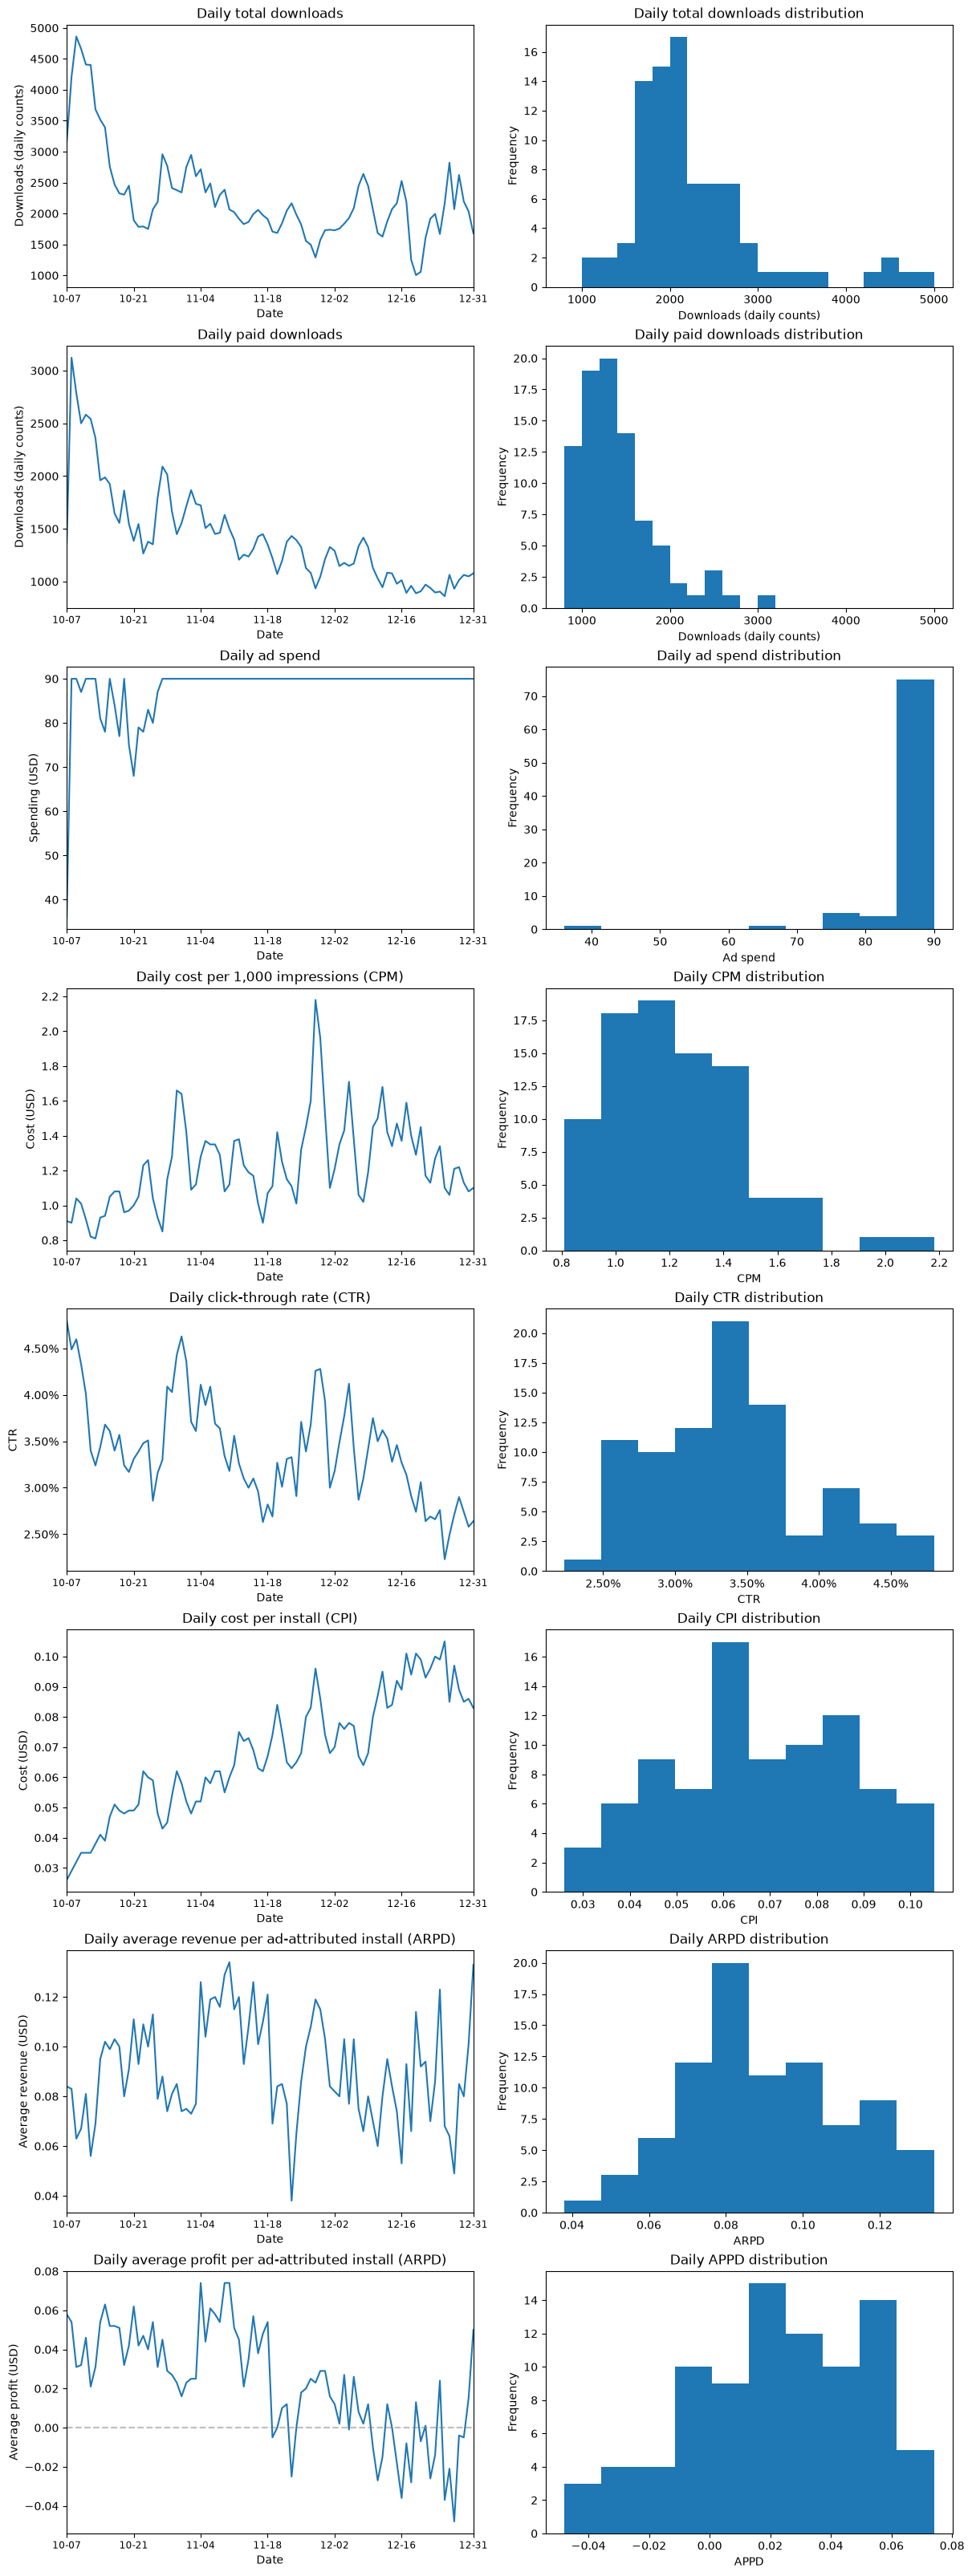

In [15]:
# To begin with, I started a side-by-side timeseries (x axis = datetime index) and distribution plots per columns originally already in the dataset.
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

fig, ax = plt.subplots(8,2, figsize=(12,32), layout="constrained")

# Row 0: total_downloads
ax[0,0].plot(promo_df.index, promo_df.total_downloads)
ax[0,0].set(xlabel="Date", ylabel="Downloads (daily counts)", title="Daily total downloads")
# For ax[0,1], I want to fix the bin to be 200 downloads per bin and span across the full range of paid and total downloads
# for visual consistency.
ax[0,1].hist(promo_df.total_downloads, bins=np.arange(800, 5200, 200))
ax[0,1].set(xlabel="Downloads (daily counts)", ylabel="Frequency", title="Daily total downloads distribution")

# Row 1: paid_downloads
ax[1,0].plot(promo_df.index, promo_df.paid_downloads)
ax[1,0].set(xlabel="Date", ylabel="Downloads (daily counts)", title="Daily paid downloads")
ax[1,1].hist(promo_df.paid_downloads, bins=np.arange(800, 5200, 200))
ax[1,1].set(xlabel="Downloads (daily counts)", ylabel="Frequency", title="Daily paid downloads distribution")

# Row 2: ad_spend
ax[2,0].plot(promo_df.index, promo_df.ad_spend)
ax[2,0].set(xlabel="Date", ylabel="Spending (USD)", title="Daily ad spend")
ax[2,1].hist(promo_df.ad_spend)
ax[2,1].set(xlabel="Ad spend", ylabel="Frequency", title="Daily ad spend distribution")

# Row 3: cpm
ax[3,0].plot(promo_df.index, promo_df.cpm)
ax[3,0].set(xlabel="Date", ylabel="Cost (USD)", title="Daily cost per 1,000 impressions (CPM)")
ax[3,1].hist(promo_df.cpm)
ax[3,1].set(xlabel="CPM", ylabel="Frequency", title="Daily CPM distribution")

# Row 4: ctr
ax[4,0].plot(promo_df.index, promo_df.ctr)
ax[4,0].set(xlabel="Date", ylabel="CTR", title="Daily click-through rate (CTR)")
ax[4,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[4,1].hist(promo_df.ctr)
ax[4,1].set(xlabel="CTR", ylabel="Frequency", title="Daily CTR distribution")
ax[4,1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Row 5: cpi
ax[5,0].plot(promo_df.index, promo_df.cpi)
ax[5,0].set(xlabel="Date", ylabel="Cost (USD)", title="Daily cost per install (CPI)")
ax[5,1].hist(promo_df.cpi)
ax[5,1].set(xlabel="CPI", ylabel="Frequency", title="Daily CPI distribution")

# Row 6: arpd
ax[6,0].plot(promo_df.index, promo_df.arpd)
ax[6,0].set(xlabel="Date", ylabel="Average revenue (USD)", title="Daily average revenue per ad-attributed install (ARPD)")
ax[6,1].hist(promo_df.arpd)
ax[6,1].set(xlabel="ARPD", ylabel="Frequency", title="Daily ARPD distribution")

# Row 7: appd
ax[7,0].plot(promo_df.index, promo_df.appd)
ax[7,0].axhline(y=0, color="tab:gray", linestyle="--", alpha=0.5)
ax[7,0].set(xlabel="Date", ylabel="Average profit (USD)", title="Daily average profit per ad-attributed install (ARPD)")
ax[7,1].hist(promo_df.appd)
ax[7,1].set(xlabel="APPD", ylabel="Frequency", title="Daily APPD distribution")

for a in ax[:,0]:
  format_date_axis(a, promo_df.index)

plt.show()

## 3. Performance evaluation
In this section, I set out to understand the performance of this ad campaign. As I could not learn the true objectives of this ad campaign from a marketing team (or the provider of this dataset), I made some reasonable assumptions about what performance might mean in the business context.

Given this app-install campaign, performance can most likely be understood in:
* how well this campaign increased the number of app installs
* whether this campaign was profitable by comparing revenue and cost reasonably attributed to it.

The following explored these two ways of understanding performance.

### 3a. Campaign effects on downloads


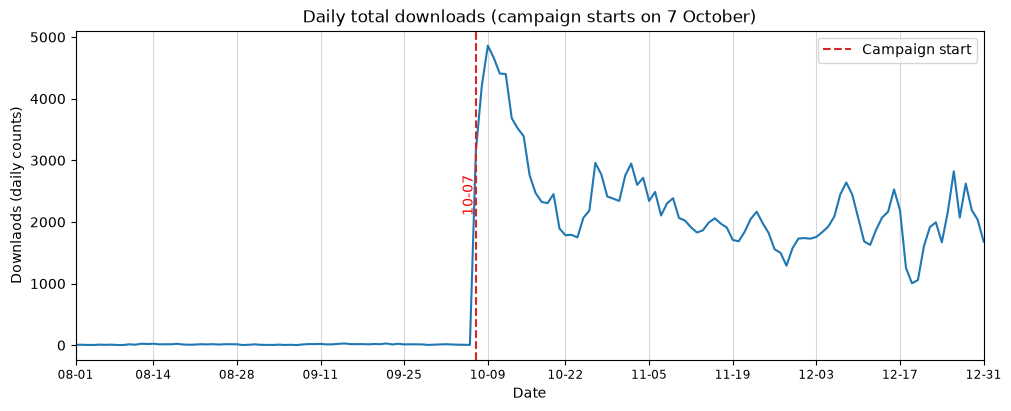

In [16]:
# [Presentation] Daily total downloads comparison before and after promotional campaign
fig, ax = plt.subplots(figsize=(10,4), layout="constrained")

# Daily total downloads
ax.plot(download_df.index, download_df.total_downloads)
ax.set(xlabel="Date", ylabel="Downlaods (daily counts)", title="Daily total downloads (campaign starts on 7 October)")

# Marking campaign start date on the graph
campaign_start = pd.Timestamp("2025-10-07")
ymin, ymax = ax.get_ylim()
ymid = (ymin + ymax) / 2
ax.axvline(campaign_start, linestyle="--", color="tab:red", label="Campaign start")
ax.text(campaign_start, ymid, campaign_start.strftime("%m-%d"), color="red", rotation=90, va="center", ha="right")

format_date_axis(ax, download_df.index, n_ticks=12)
ax.grid(alpha=0.5, axis="x")

plt.legend()
plt.show()

In [17]:
# [Presentation] Calculate daily downloads by monthly averages

totalDownload_monthly = download_df.resample("MS").sum()
totalDownload_monthly["avgDaily_totalDownloads"] = download_df.resample("MS").mean()

# Note: since promo_df only concerns the campaign duration, all data starts on 7 October (instead of 1 October)
paidDownload_monthly = promo_df.resample("MS")[["paid_downloads", "total_downloads"]].sum()
paidDownload_monthly["avgDaily_paidDownloads"] = promo_df.resample("MS")[["paid_downloads"]].mean()
paidDownload_monthly["avgDaily_totalDownloads"] = promo_df.resample("MS")[["total_downloads"]].mean()
nonpaidDownload_monthly = promo_df[["nonpaid_downloads"]].resample("MS").sum()
nonpaidDownload_monthly["avgDaily_nonpaidDownloads"] = promo_df.nonpaid_downloads.resample("MS").mean()

download_monthly = pd.merge(totalDownload_monthly, paidDownload_monthly, left_index=True, right_index=True, how="outer", suffixes=("", "_Oct7"))
download_monthly = pd.merge(download_monthly, nonpaidDownload_monthly, left_index=True, right_index=True, how="outer")
delta = download_df.loc["2025-10-01":"2025-10-06", "total_downloads"].sum()

# To compare between pre- and post-campaign download levels, I used September and October data (while excluding 1-6 October)
sep = download_monthly.loc["2025-09"].squeeze()
oct = download_monthly.loc["2025-10"].squeeze()
print(f"Between September and October (the campaign start), the number of total downloads increased by {100 * (oct["total_downloads"] - sep["total_downloads"]) / sep["total_downloads"]:.2f}%.")
print(f"Average daily total downloads went from {sep["avgDaily_totalDownloads"]:.2f} in September to {oct["avgDaily_totalDownloads_Oct7"]:.2f} in October, increasing by {(oct["avgDaily_totalDownloads_Oct7"] - sep["avgDaily_totalDownloads"]) / sep["avgDaily_totalDownloads"]:.2f} folds, excluding the 1-6 October non-campaign period.")
print(f"In October, {100* oct["paid_downloads"] / oct["total_downloads"]:.2f}% was paid downloads, and {100* oct["nonpaid_downloads"] / oct["total_downloads"]:.2f}% was organic downloads.")
print(f"Since the campaign started, daily organic traffic increased by {(oct["avgDaily_nonpaidDownloads"] - sep["avgDaily_totalDownloads"]) / sep["avgDaily_totalDownloads"]:.2f} folds in the first month, excluding the 1-6 October non-campaign period.")
download_monthly

Between September and October (the campaign start), the number of total downloads increased by 17362.20%.
Average daily total downloads went from 13.93 in September to 2917.24 in October, increasing by 208.37 folds, excluding the 1-6 October non-campaign period.
In October, 64.71% was paid downloads, and 35.20% was organic downloads.
Since the campaign started, daily organic traffic increased by 72.77 folds in the first month, excluding the 1-6 October non-campaign period.


,total_downloads,avgDaily_totalDownloads,paid_downloads,total_downloads_Oct7,avgDaily_paidDownloads,avgDaily_totalDownloads_Oct7,nonpaid_downloads,avgDaily_nonpaidDownloads
date,,,,,,,,
2025-08-01,367,11.838710,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-01,418,13.933333,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-01,72992,2354.580645,47236.0,72931.0,1889.440000,2917.240000,25695.0,1027.800000
2025-11-01,61170,2039.000000,41204.0,61170.0,1373.466667,2039.000000,19966.0,665.533333
2025-12-01,60905,1964.677419,33025.0,60905.0,1065.322581,1964.677419,27880.0,899.354839


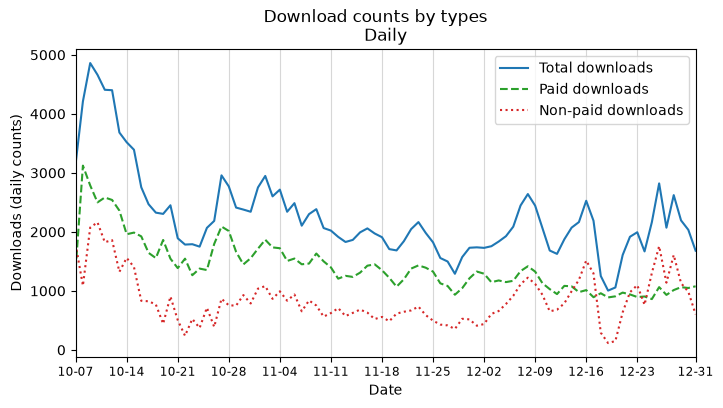

In [18]:
# [Presentation] Splitting total downloads by type

windows = [7, 30]

paidInst_df = sma_rolling_mean(promo_df[["paid_downloads"]], windows=windows, numerator="paid_downloads")
totalInst_df = sma_rolling_mean(promo_df[["total_downloads"]], windows=windows, numerator="total_downloads")
nonpaidInst_df = sma_rolling_mean(promo_df[["nonpaid_downloads"]], windows=windows, numerator="nonpaid_downloads")

fig, ax = plt.subplots(figsize=(8,4))

# ax[0,0] daily
ax.plot(promo_df.index, totalInst_df.total_downloads, label="Total downloads", color="tab:blue")
ax.plot(promo_df.index, paidInst_df.paid_downloads, label="Paid downloads", color="tab:green", linestyle="--")
ax.plot(promo_df.index, nonpaidInst_df.nonpaid_downloads, label="Non-paid downloads", color="tab:red", linestyle=":")
ax.set(xlabel="Date", ylabel="Downloads (daily counts)", title="Daily")

format_date_axis(ax, promo_df.index, n_ticks=13)
ax.legend()
ax.grid(alpha=0.5, axis="x")

plt.suptitle("Download counts by types")
plt.show()

### 3b. Campaign profitability: Cost, revenue, and profit

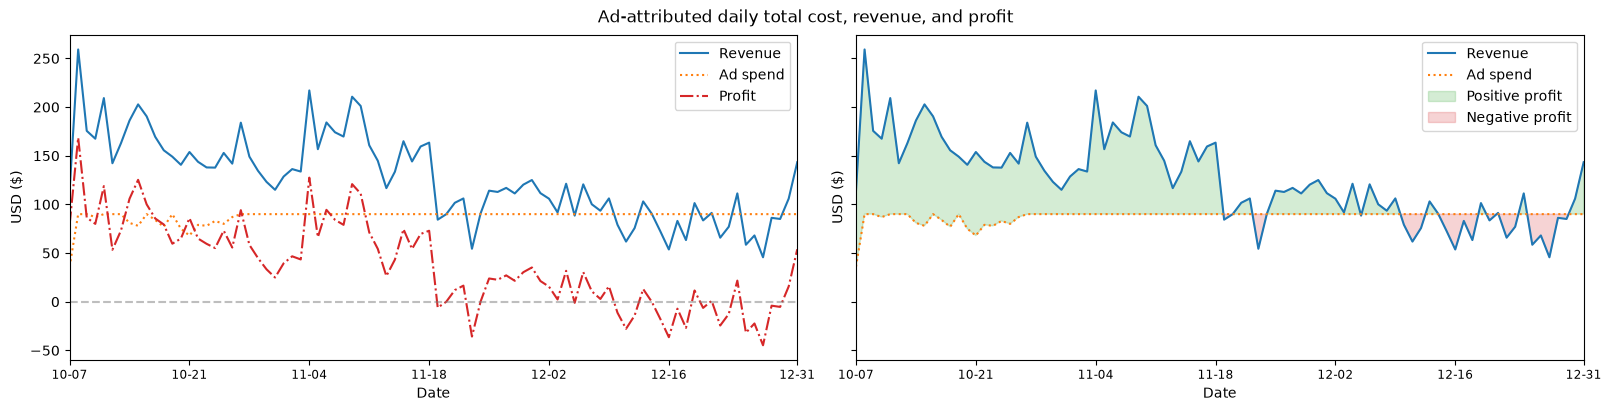

In [19]:
# [Presentation] Plotting daily cost, revenue, and profit in absolutes
fig, ax = plt.subplots(1,2, figsize=(16,4), sharey=True, layout="constrained")
fill_condition = promo_df.trpd - promo_df.ad_spend

# ax[0] All as 3 separate lines
ax[0].plot(promo_df.index, promo_df.trpd, label="Revenue", color="tab:blue")
ax[0].plot(promo_df.index, promo_df.ad_spend, label="Ad spend", linestyle=":", color="tab:orange")
ax[0].plot(promo_df.index, promo_df.tppd, label="Profit", linestyle="-.", color="tab:red")
ax[0].axhline(y=0, color="tab:gray", linestyle="--", alpha=0.5)
ax[0].set(xlabel="Date", ylabel="USD ($)")

# ax[1] Profit as shaded differences between revenue and cost
ax[1].plot(promo_df.index, promo_df.trpd, label="Revenue", color="tab:blue")
ax[1].plot(promo_df.index, promo_df.ad_spend, label="Ad spend", linestyle=":", color="tab:orange")
ax[1].fill_between(promo_df.index, promo_df.trpd, promo_df.ad_spend, label="Positive profit", where=(fill_condition >= 0), interpolate=True, color="tab:green", alpha=0.2)
ax[1].fill_between(promo_df.index, promo_df.trpd, promo_df.ad_spend, label="Negative profit", where=(fill_condition <= 0), interpolate=True, color="tab:red", alpha=0.2)
ax[1].set(xlabel="Date", ylabel="USD ($)")

for i, a in enumerate(ax):
  format_date_axis(a, promo_df.index)
  a.legend()

plt.suptitle("Ad-attributed daily total cost, revenue, and profit")
plt.legend()
plt.show()

In [20]:
# [Presentation] Monthly profits
profitability_monthly = promo_df.resample("MS")[["ad_spend", "trpd", "tppd"]].sum()
diff = profitability_monthly.diff()
pct_change = profitability_monthly.pct_change()
profitability_monthly = pd.merge(profitability_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
profitability_monthly = pd.merge(profitability_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pctChange"))

print(f"Total revenue during campaign: {profitability_monthly.trpd.sum()}")
print(f"Total cost during campaign: {profitability_monthly.ad_spend.sum()}")
print(f"Total profit during campaign: {profitability_monthly.tppd.sum()}")

profitability_monthly

Total revenue during campaign: 10872.438999999998
Total cost during campaign: 7563
Total profit during campaign: 3309.9139999999998


,ad_spend,trpd,tppd,ad_spend_diff,trpd_diff,tppd_diff,ad_spend_pctChange,trpd_pctChange,tppd_pctChange
date,,,,,,,,,
2025-10-01,2073,3999.515,1929.858,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,2700,4127.767,1426.667,627.0,128.252,-503.191,0.302460,0.032067,-0.260740
2025-12-01,2790,2745.157,-46.611,90.0,-1382.610,-1473.278,0.033333,-0.334953,-1.032671


Over the entire campaign period (7 Oct to 31 Dec), the campaign performance is as follows:
Revenue: 10872.439
Cost: 7563
Net profit: 3309.914
Return on Ad Spend (ROAS = Revenue ÷ Ad Spend): 143.76%


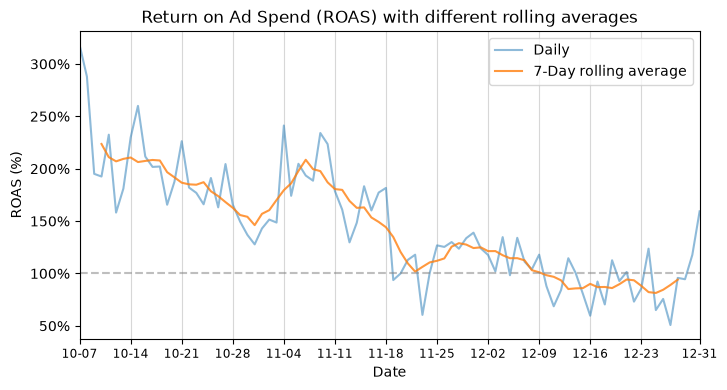

In [21]:
# [Presentation] Calculate and visualize ROAS
overall_roas = promo_df.trpd.sum() / promo_df.ad_spend.sum()

print(f"Over the entire campaign period (7 Oct to 31 Dec), the campaign performance is as follows:")
print(f"Revenue: {promo_df.trpd.sum()}")
print(f"Cost: {promo_df.ad_spend.sum()}")
print(f"Net profit: {promo_df.tppd.sum()}")
print(f"Return on Ad Spend (ROAS = Revenue ÷ Ad Spend): {overall_roas*100:.2f}%")

# Using moving averages to smooth out daily fluctuations but still highlight relevant trends. 
windows = [7]
roas_df = promo_df[["ad_spend", "trpd", "roas"]].copy()
numerators = list(roas_df.columns)
for a in numerators:
  roas_df = sma_rolling_mean(roas_df, windows=windows, numerator=a)

# Plot it
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(roas_df.index, roas_df.roas, label="Daily", alpha=0.5)
ax.plot(roas_df.index, roas_df.roas_sma_7d, label="7-Day rolling average", alpha=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(y=1, color="tab:gray", linestyle="--", alpha=0.5)
ax.set(xlabel="Date", ylabel="ROAS (%)", title="Return on Ad Spend (ROAS) with different rolling averages")

format_date_axis(ax, roas_df.index, n_ticks=13)
ax.legend()
ax.grid(alpha=0.5, axis="x")

plt.show()

## 4. Problem: Declining revenue
In this section, I explored two leading hypotheses for declining revenue (which was the reason for declining campaign profitability, shown in 3b).

Daily total revenue = ARPD $\times$ daily ad spend.

Given the above equation, I explored two hypotheses:
* Paid download users were spending less: if this is true, we should see a declining ARPD over time
* There were less paid downloads: if this is true, then we should see declining paid downloads, with other user engagement metrics (impressions, clicks, etc.) also decreasing over time

### 4a. Hypothesis 1: *"Paid download users were spending less"*

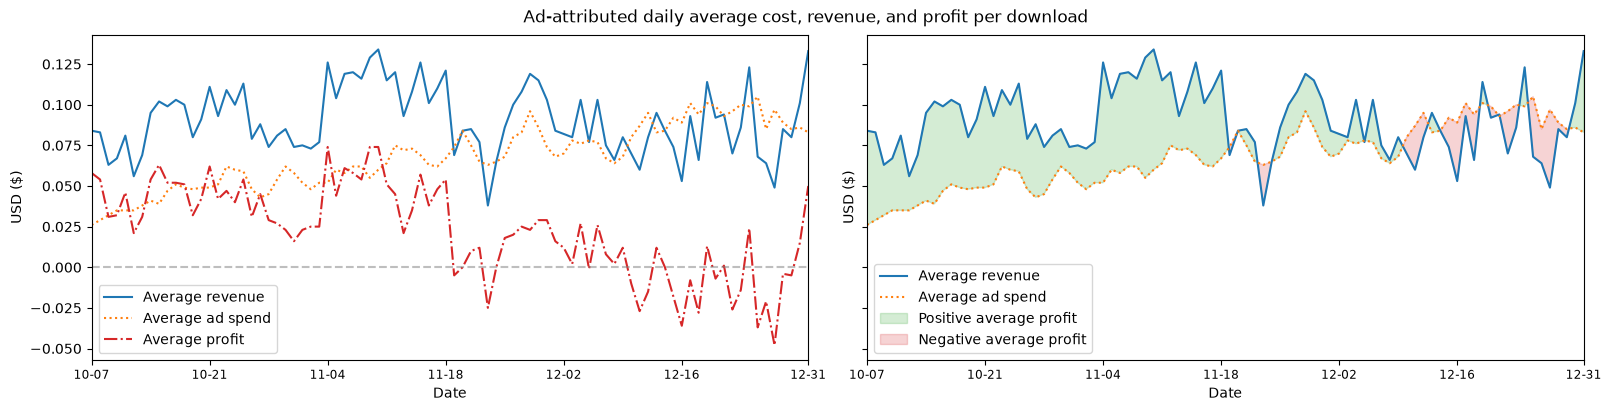

In [22]:
# Plotting daily cost, revenue, and profit in averages (per ad-attributed download)
fig, ax = plt.subplots(1,2, figsize=(16,4), sharey=True, layout="constrained")
fill_condition = promo_df.arpd - promo_df.cpi

# ax[0] All as 3 separate lines
ax[0].plot(promo_df.index, promo_df.arpd, label="Average revenue", color="tab:blue")
ax[0].plot(promo_df.index, promo_df.cpi, label="Average ad spend", linestyle=":", color="tab:orange")
ax[0].plot(promo_df.index, promo_df.appd, label="Average profit", linestyle="-.", color="tab:red")
ax[0].axhline(y=0, color="tab:gray", linestyle="--", alpha=0.5)
ax[0].set(xlabel="Date", ylabel="USD ($)")

# ax[1] Profit as shaded differences between revenue and cost
ax[1].plot(promo_df.index, promo_df.arpd, label="Average revenue", color="tab:blue")
ax[1].plot(promo_df.index, promo_df.cpi, label="Average ad spend", linestyle=":", color="tab:orange")
ax[1].fill_between(promo_df.index, promo_df.arpd, promo_df.cpi, label="Positive average profit", where=(fill_condition >= 0), interpolate=True, color="tab:green", alpha=0.2)
ax[1].fill_between(promo_df.index, promo_df.arpd, promo_df.cpi, label="Negative average profit", where=(fill_condition <= 0), interpolate=True, color="tab:red", alpha=0.2)
ax[1].set(xlabel="Date", ylabel="USD ($)")

for i, a in enumerate(ax):
  format_date_axis(a, promo_df.index)
  a.legend()

plt.suptitle("Ad-attributed daily average cost, revenue, and profit per download")
plt.legend()
plt.show()

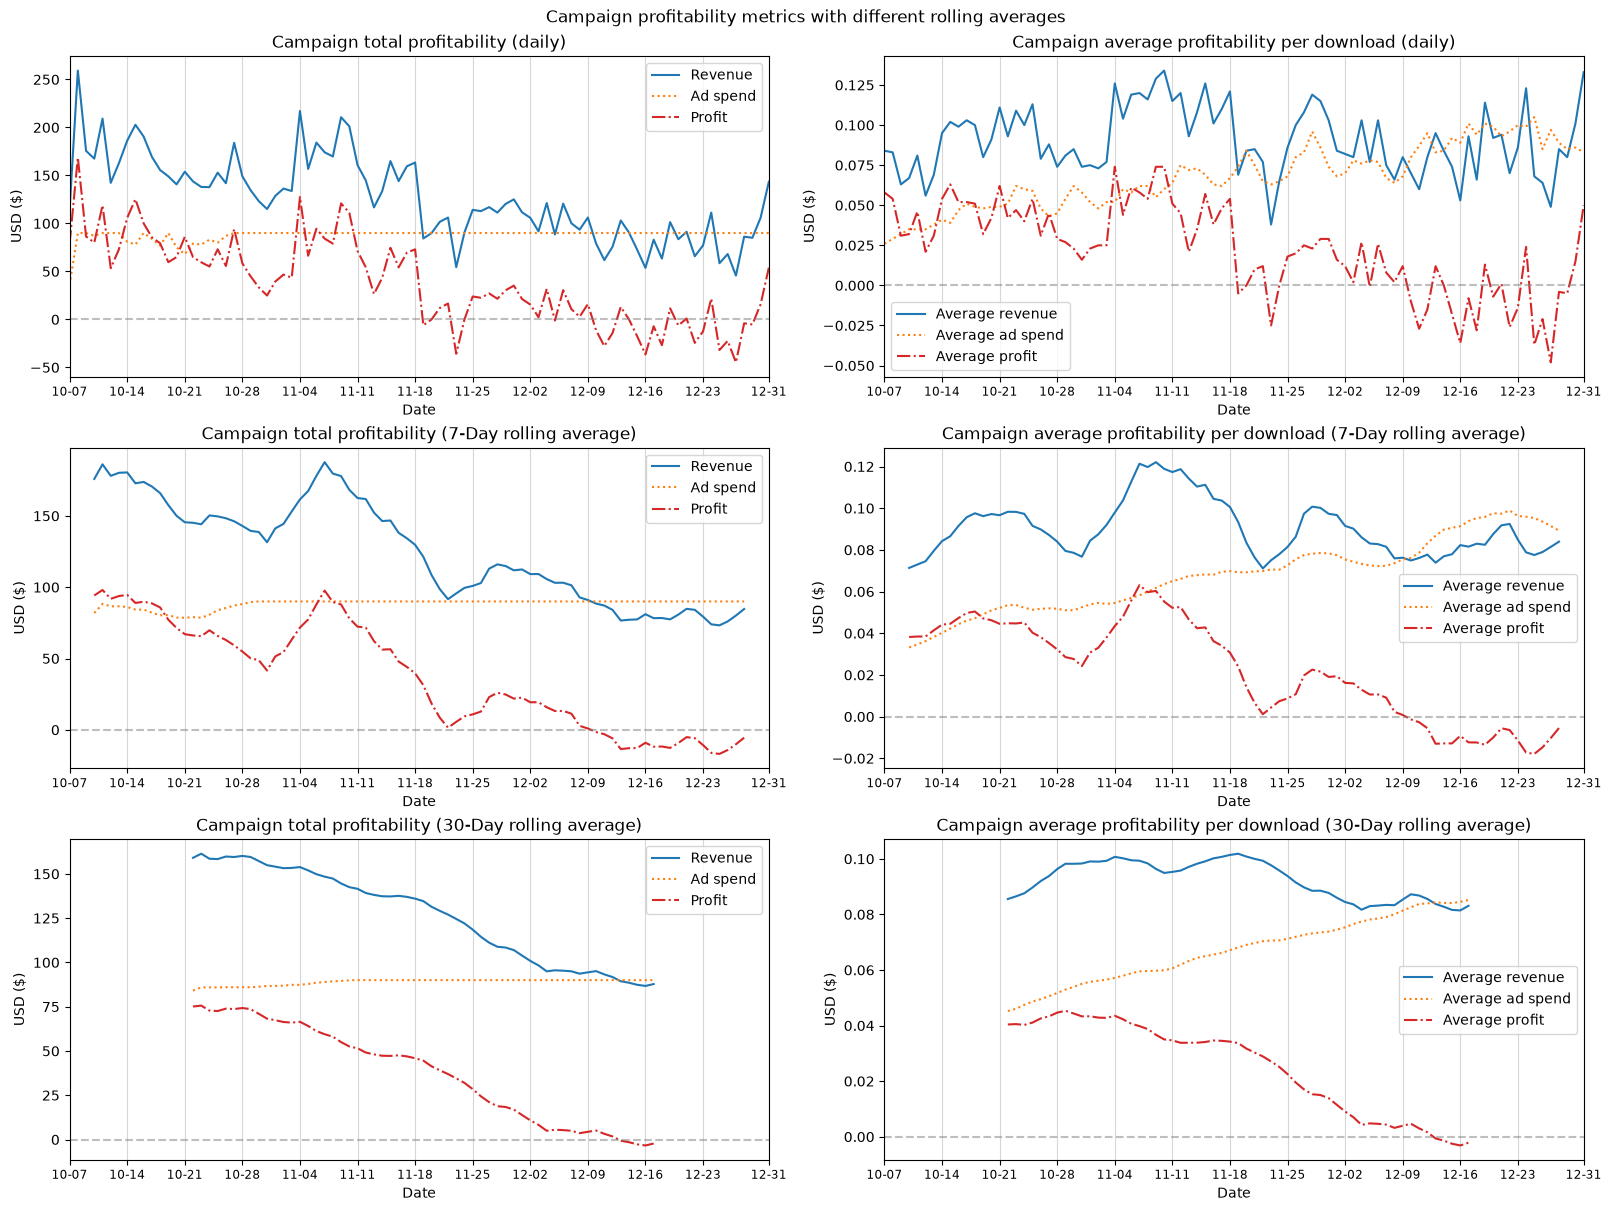

In [23]:
# [Presentation] Use rolling averages to smooth out daily fluctuations but retain key information
windows=[7, 30]
profit_cols = ["ad_spend", "trpd", "tppd", "cpi", "arpd", "appd", "paid_downloads"]
profit_df = promo_df[profit_cols].copy()

for a in profit_cols:
  if a in ["ad_spend", "trpd", "tppd"]:
    profit_df = sma_rolling_mean(profit_df, windows=windows, numerator=a)
  elif a in ["cpi", "arpd", "appd"]:
    if a == "cpi":
      profit_df = sma_rolling_mean(profit_df, windows=windows, numerator="ad_spend", rate_mean=True, denominator="paid_downloads", name="cpi")
    elif a == "arpd":
      profit_df = sma_rolling_mean(profit_df, windows=windows, numerator="trpd", rate_mean=True, denominator="paid_downloads", name="arpd")
    elif a == "appd":
      profit_df = sma_rolling_mean(profit_df, windows=windows, numerator="tppd", rate_mean=True, denominator="paid_downloads", name="appd")
  else:
    pass

def campaign_profit_plots(a, df, rolling_avg, revenue, cost, profit, absolute=True):
  if absolute:
    a.plot(df.index, df[revenue], label="Revenue", color="tab:blue")
    a.plot(df.index, df[cost], label="Ad spend", linestyle=":", color="tab:orange")
    a.plot(df.index, df[profit], label="Profit", linestyle="-.", color="tab:red")
    a.axhline(y=0, color="tab:gray", linestyle="--", alpha=0.5)
    a.set(xlabel="Date", ylabel="USD ($)")
    if rolling_avg == "Daily":
      a.set(title=f"Campaign total profitability (daily)")
    else:
      a.set(title=f"Campaign total profitability ({rolling_avg} rolling average)")
    
  else:
    a.plot(df.index, df[revenue], label="Average revenue", color="tab:blue")
    a.plot(df.index, df[cost], label="Average ad spend", linestyle=":", color="tab:orange")
    a.plot(df.index, df[profit], label="Average profit", linestyle="-.", color="tab:red")
    a.axhline(y=0, color="tab:gray", linestyle="--", alpha=0.5)
    a.set(xlabel="Date", ylabel="USD ($)", title=f"Campaign average profitability per download ({rolling_avg} average)")
    a.set(xlabel="Date", ylabel="USD ($)")
    if rolling_avg == "Daily":
      a.set(title=f"Campaign average profitability per download (daily)")
    else:
      a.set(title=f"Campaign average profitability per download ({rolling_avg} rolling average)")

rolling_avgs = ["Daily", "7-Day", "30-Day"]

# Plot it
fig, ax = plt.subplots(3,2, figsize=(16,12), layout="constrained")

# Absolute graphs are on the left
for i, a in enumerate(ax[:, 0]):
  absolute = True
  rolling_avg = rolling_avgs[i]
  revenue, cost, profit = "trpd", "ad_spend", "tppd"
  if rolling_avg == "Daily":
    pass
  elif rolling_avg == "7-Day":
    revenue, cost, profit = revenue + "_sma_7d", cost + "_sma_7d", profit + "_sma_7d"
  elif rolling_avg == "30-Day":
    revenue, cost, profit = revenue + "_sma_30d", cost + "_sma_30d", profit + "_sma_30d"
  else:
    print(f"{rolling_avg} not found in rolling_avgs")
  campaign_profit_plots(a=a, df=profit_df, rolling_avg=rolling_avg, revenue=revenue, cost=cost, profit=profit, absolute=absolute)
  format_date_axis(a, profit_df.index, n_ticks=13)
  a.legend()
  a.grid(alpha=0.5, axis="x")

# Average per download graphs are on the right
for i, a in enumerate(ax[:, 1]):
  absolute = False
  rolling_avg = rolling_avgs[i]
  revenue, cost, profit = "arpd", "cpi", "appd"
  if rolling_avg == "Daily":
    pass
  elif rolling_avg == "7-Day":
    revenue, cost, profit = revenue + "_sma_7d", cost + "_sma_7d", profit + "_sma_7d"
  elif rolling_avg == "30-Day":
    revenue, cost, profit = revenue + "_sma_30d", cost + "_sma_30d", profit + "_sma_30d"
  else:
    print(f"{rolling_avg} not found in rolling_avgs")
  campaign_profit_plots(a=a, df=profit_df, rolling_avg=rolling_avg, revenue=revenue, cost=cost, profit=profit, absolute=absolute)
  format_date_axis(a, profit_df.index, n_ticks=13)
  a.legend()
  a.grid(alpha=0.5, axis="x")

plt.suptitle("Campaign profitability metrics with different rolling averages")
plt.show()

In [24]:
# [Presentation] Average profit per paid download by month
paidDownloads_monthly = promo_df.resample("MS")[["paid_downloads"]].sum()
profitability_monthly = promo_df.resample("MS")[["ad_spend", "trpd", "tppd"]].sum()

avgProfitability_monthly = pd.DataFrame()
avgProfitability_monthly["cpi"] = profitability_monthly["ad_spend"] / paidDownloads_monthly["paid_downloads"]
avgProfitability_monthly["arpd"] = profitability_monthly["trpd"] / paidDownloads_monthly["paid_downloads"]
avgProfitability_monthly["appd"] = profitability_monthly["tppd"] / paidDownloads_monthly["paid_downloads"]

diff = avgProfitability_monthly.diff()
pct_change = avgProfitability_monthly.pct_change()

avgProfitability_monthly = pd.merge(avgProfitability_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
avgProfitability_monthly = pd.merge(avgProfitability_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pctChange"))

print("Between October and December,")
print(f"ARPD total change {avgProfitability_monthly.arpd_diff.sum()}, total percentage change {100 * avgProfitability_monthly.arpd_diff.sum()/avgProfitability_monthly.loc["2025-10-01", "arpd"]:.2f}%.")
print(f"CPI total change {avgProfitability_monthly.cpi_diff.sum()}, total percentage change {100 * avgProfitability_monthly.cpi_diff.sum()/avgProfitability_monthly.loc["2025-10-01", "cpi"]:.2f}%.")

avgProfitability_monthly

Between October and December,
ARPD total change -0.001547304451390022, total percentage change -1.83%.
CPI total change 0.040595434306414706, total percentage change 92.50%.


,cpi,arpd,appd,cpi_diff,arpd_diff,appd_diff,cpi_pctChange,arpd_pctChange,appd_pctChange
date,,,,,,,,,
2025-10-01,0.043886,0.084671,0.040856,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,0.065528,0.100179,0.034624,0.021642,0.015508,-0.006231,0.493132,0.183155,-0.152517
2025-12-01,0.084481,0.083124,-0.001411,0.018954,-0.017055,-0.036036,0.289250,-0.170248,-1.040763


### 4b. Hypothesis 2: *“There were less paid downloads”*

In [25]:
# [Presentation] Daily paid download changes through months
paidDownload_monthly = download_monthly.loc["2025-10":"2025-12", ["paid_downloads", "avgDaily_paidDownloads"]].copy()
diff = paidDownload_monthly.diff()
pct_change = paidDownload_monthly.pct_change()

paidDownload_monthly = pd.merge(paidDownload_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
paidDownload_monthly = pd.merge(paidDownload_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pct_change"))

print(f"Monthly paid downloads changed by {100 * paidDownload_monthly.paid_downloads_diff.sum() / paidDownload_monthly.loc["2025-10-01", "paid_downloads"]:.2f}%.")
print(f"Monthly average Daily paid downloads changed by {100 * paidDownload_monthly.avgDaily_paidDownloads_diff.sum() / paidDownload_monthly.loc["2025-10-01", "avgDaily_paidDownloads"]:.2f}%.")
paidDownload_monthly

Monthly paid downloads changed by -30.09%.
Monthly average Daily paid downloads changed by -43.62%.


,paid_downloads,avgDaily_paidDownloads,paid_downloads_diff,avgDaily_paidDownloads_diff,paid_downloads_pct_change,avgDaily_paidDownloads_pct_change
date,,,,,,
2025-10-01,47236.0,1889.440000,NaN,NaN,NaN,NaN
2025-11-01,41204.0,1373.466667,-6032.0,-515.973333,-0.127699,-0.273083
2025-12-01,33025.0,1065.322581,-8179.0,-308.144086,-0.198500,-0.224355


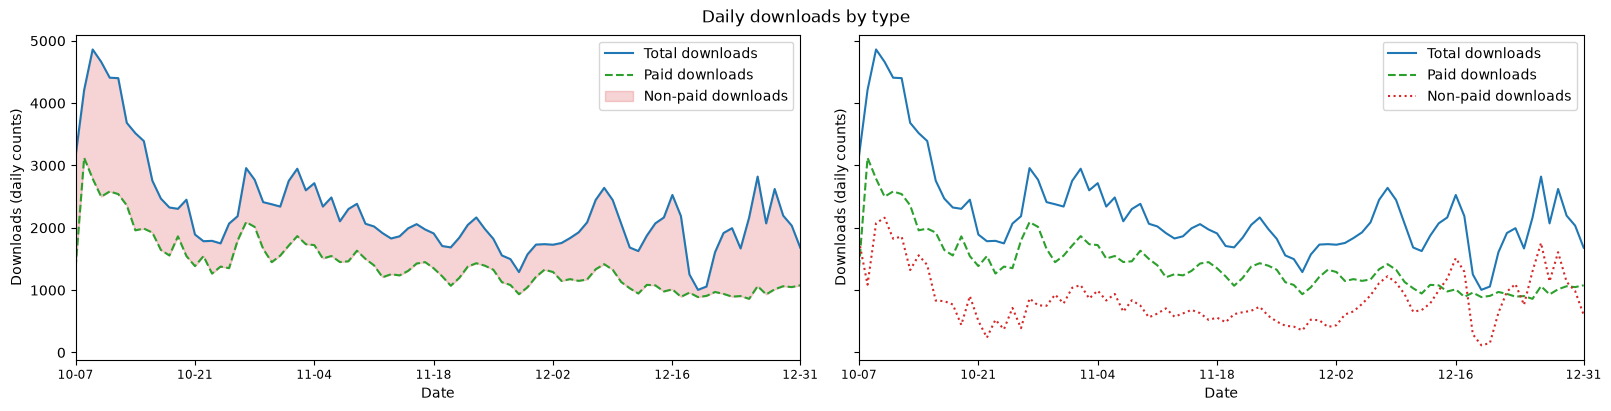

In [26]:
# Plotting daily total downloads, paid downloads, and non-paid downloads since the campaign started (7 Oct)
fig, ax = plt.subplots(1,2, figsize=(16,4), sharey=True, layout="constrained")

# Non-paid downloads as shaded differences between total and paid downloads
ax[0].plot(promo_df.index, promo_df.total_downloads, label="Total downloads", color="tab:blue")
ax[0].plot(promo_df.index, promo_df.paid_downloads, label="Paid downloads", linestyle="--", color="tab:green")
ax[0].fill_between(promo_df.index, promo_df.total_downloads, promo_df.paid_downloads, label="Non-paid downloads", color="tab:red", alpha=0.2)
ax[0].set(xlabel="Date", ylabel="Downloads (daily counts)")

# All as 3 separate lines
ax[1].plot(promo_df.index, promo_df.total_downloads, label="Total downloads", color="tab:blue")
ax[1].plot(promo_df.index, promo_df.paid_downloads, label="Paid downloads", linestyle="--", color="tab:green")
ax[1].plot(promo_df.index, promo_df.nonpaid_downloads, label="Non-paid downloads", linestyle=":", color="tab:red")
ax[1].set(xlabel="Date", ylabel="Downloads (daily counts)")

for i, a in enumerate(ax):
  format_date_axis(a, promo_df.index)
  a.legend()

plt.suptitle("Daily downloads by type")
plt.legend()
plt.show()

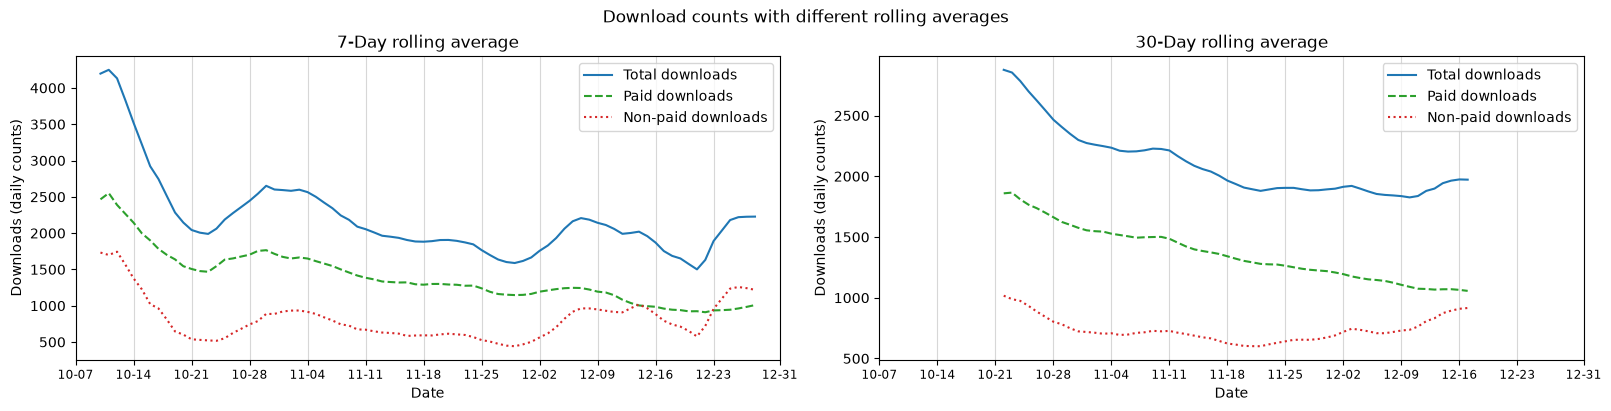

In [27]:
# [Presentation] To show the trends more clearly, I use simple moving averages (SMA) to smooth out daily fluctuations yet retain important trends.
windows = [7, 30]

paidInst_df = sma_rolling_mean(promo_df[["paid_downloads"]], windows=windows, numerator="paid_downloads")
totalInst_df = sma_rolling_mean(promo_df[["total_downloads"]], windows=windows, numerator="total_downloads")
nonpaidInst_df = sma_rolling_mean(promo_df[["nonpaid_downloads"]], windows=windows, numerator="nonpaid_downloads")

# Plot it
fig, ax = plt.subplots(1,2, figsize=(16,4), layout="constrained")

# ax[0] 7-day rolling avg
ax[0].plot(promo_df.index, totalInst_df.total_downloads_sma_7d, label="Total downloads", color="tab:blue")
ax[0].plot(promo_df.index, paidInst_df.paid_downloads_sma_7d, label="Paid downloads", color="tab:green", linestyle="--")
ax[0].plot(promo_df.index, nonpaidInst_df.nonpaid_downloads_sma_7d, label="Non-paid downloads", color="tab:red", linestyle=":")
ax[0].set(xlabel="Date", ylabel="Downloads (daily counts)", title="7-Day rolling average")

# ax[1] 30-day rolling avg
ax[1].plot(promo_df.index, totalInst_df.total_downloads_sma_30d, label="Total downloads", color="tab:blue")
ax[1].plot(promo_df.index, paidInst_df.paid_downloads_sma_30d, label="Paid downloads", color="tab:green", linestyle="--")
ax[1].plot(promo_df.index, nonpaidInst_df.nonpaid_downloads_sma_30d, label="Non-paid downloads", color="tab:red", linestyle=":")
ax[1].set(xlabel="Date", ylabel="Downloads (daily counts)", title="30-Day rolling average")

for a in ax.flat:
  format_date_axis(a, promo_df.index, n_ticks=13)
  a.legend()
  a.grid(alpha=0.5, axis="x")

plt.suptitle("Download counts with different rolling averages")
plt.show()

#### Dissecting the ad funnel

In this following section, I further looked into what metrics tracking the ad funnel might explain the declining paid downloads.

The full ad funnel should be the following:

Ad spend --CPM--> Impression --CTR--> Clicks --CIR--> Paid Downloads

##### Top of the funnel (TOFU): Ad spend --CPM--> Impression
The very top part of the funnel is when money spent on ads successfully increased the number of impressions, or the number of times Facebook users have seen the ad. 

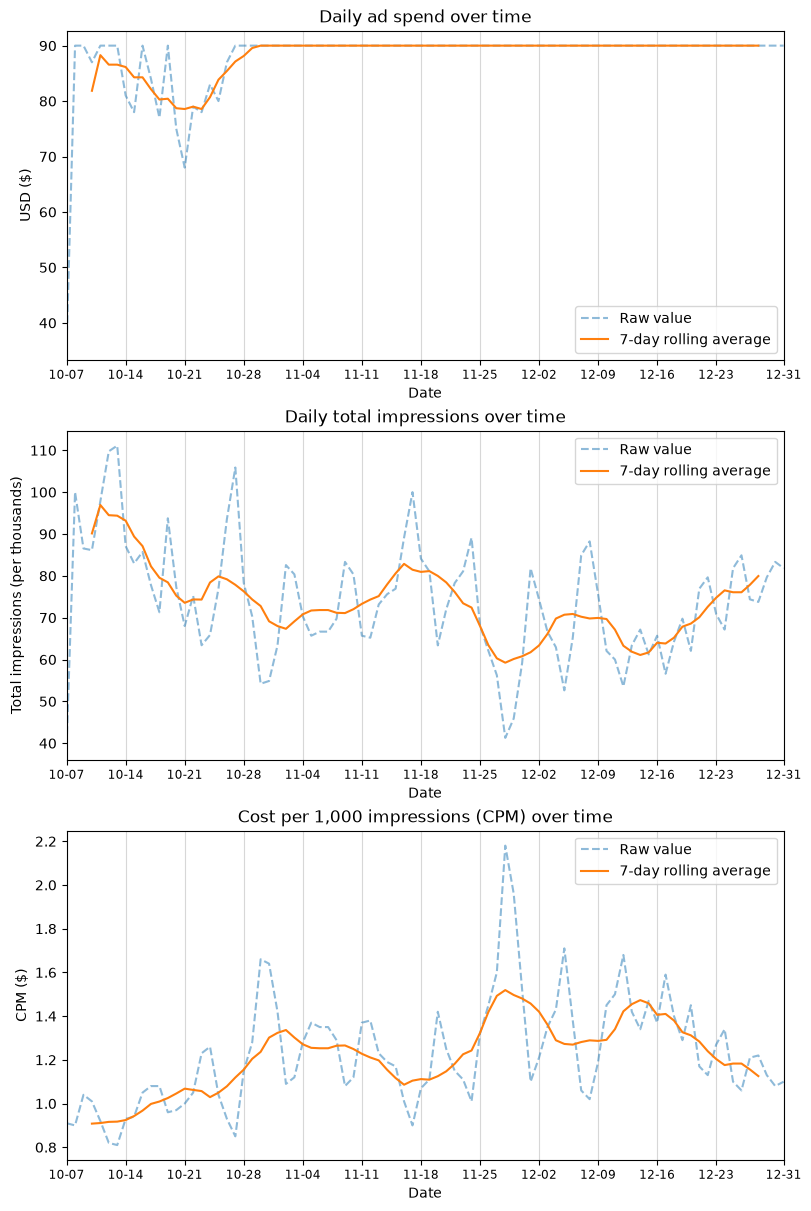

In [28]:
# [Presentation] Trend analysis
topFunnel_df = promo_df[["ad_spend", "total_impressions", "cpm"]].copy()
for col in topFunnel_df.columns:
  if col == "cpm":
    topFunnel_df = sma_rolling_mean(topFunnel_df, windows=[7], numerator="ad_spend", rate_mean=True, denominator="total_impressions", name=col)
  else:
    topFunnel_df = sma_rolling_mean(topFunnel_df, windows=[7], numerator=col)

fig, ax = plt.subplots(3,1, figsize=(8,12), layout="constrained")

ax[0].plot(topFunnel_df.index, topFunnel_df.ad_spend, label="Raw value", linestyle="--", alpha=0.5)
ax[0].plot(topFunnel_df.index, topFunnel_df.ad_spend_sma_7d, label="7-day rolling average")
ax[0].set(xlabel="Date", ylabel="USD ($)", title="Daily ad spend over time")
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.5, axis="x")

ax[1].plot(topFunnel_df.index, topFunnel_df.total_impressions / 1000, label="Raw value", linestyle="--", alpha=0.5)
ax[1].plot(topFunnel_df.index, topFunnel_df.total_impressions_sma_7d / 1000, label="7-day rolling average")
ax[1].set(xlabel="Date", ylabel="Total impressions (per thousands)", title="Daily total impressions over time")
ax[1].legend()
ax[1].grid(alpha=0.5, axis="x")

ax[2].plot(topFunnel_df.index, topFunnel_df.cpm, label="Raw value", linestyle="--", alpha=0.5)
ax[2].plot(topFunnel_df.index, topFunnel_df.cpm_sma_7d * 1000, label="7-day rolling average")
ax[2].set(xlabel="Date", ylabel="CPM ($)", title="Cost per 1,000 impressions (CPM) over time")
ax[2].legend()
ax[2].grid(alpha=0.5, axis="x")

for a in ax.flat:
  format_date_axis(a, topFunnel_df.index, n_ticks=13)

plt.show()

In [29]:
# Total impressions outliers
impression_outliers = outlier_detector(promo_df, "total_impressions")
impression_outliers.sort_values("total_impressions", ascending=False)

Mean used: 73985.1179
Standard deviation used: 13987.4701


,ad_spend,cpm,ctr,paid_downloads,cpi,arpd,appd,total_downloads,trpd,tppd,total_impressions,total_clicks,nonpaid_downloads,cir,roas
date,,,,,,,,,,,,,,,
2025-10-13,90,0.81,0.0324,2361,0.038,0.069,0.031,3684,162.909,73.191,111111.111111,3600.000000,1323,0.655833,1.810100
2025-10-12,90,0.82,0.0340,2541,0.035,0.056,0.021,4401,142.296,53.361,109756.097561,3731.707317,1860,0.680922,1.581067
2025-10-27,90,0.85,0.0330,2091,0.043,0.088,0.045,2958,184.008,94.095,105882.352941,3494.117647,867,0.598434,2.044533
2025-11-29,90,1.96,0.0428,1046,0.086,0.115,0.029,1573,120.290,30.334,45918.367347,1965.306122,527,0.532233,1.336556
2025-11-28,90,2.18,0.0426,935,0.096,0.119,0.023,1290,111.265,21.505,41284.403670,1758.715596,355,0.531638,1.236278
2025-10-07,36,0.91,0.0480,1363,0.026,0.084,0.058,3154,114.492,79.054,39560.439560,1898.901099,1791,0.717784,3.180333


In [30]:
# Total impressions monthly means
print(f"Mean total impressions by month:")
print(f"October (since the 7th): {topFunnel_df.total_impressions["2025-10"].mean():.2f}")
print(f"November: {topFunnel_df.total_impressions["2025-11"].mean():.2f}")
print(f"December: {topFunnel_df.total_impressions["2025-12"].mean():.2f}")

Mean total impressions by month:
October (since the 7th): 80536.48
November: 71892.86
December: 70726.53


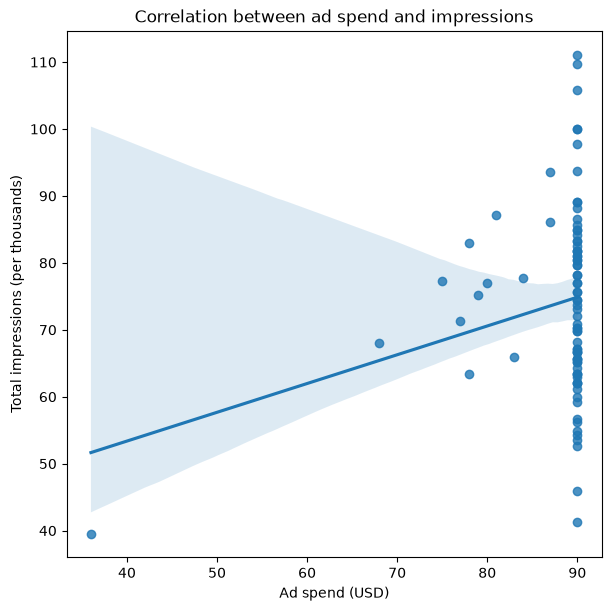

In [31]:
# [Presentation] Correlation analysis
fig, ax = plt.subplots(figsize=(6,6), layout="constrained")

sns.regplot(x=topFunnel_df.ad_spend, y=topFunnel_df.total_impressions / 1000)
ax.set(xlabel="Ad spend (USD)", ylabel="Total impressions (per thousands)", title="Correlation between ad spend and impressions")

plt.show()

In [32]:
# [Presentation] Correlation analysis
results = []
pairs = [["ad_spend", "total_impressions"], ["ad_spend_sma_7d", "total_impressions_sma_7d"]]

for pair in pairs:
  f1 = pair[0]
  f2 = pair[1]
  r, p = stats.pearsonr(topFunnel_df[f1].dropna(), topFunnel_df[f2].dropna())
  results.append({"Feature 1": f1, "Feature 2": f2, "Correlation": r, "p-value": p})

topFunnel_corr_df = pd.DataFrame(results)

topFunnel_corr_df

,Feature 1,Feature 2,Correlation,p-value
0,ad_spend,total_impressions,0.214026,0.047844
1,ad_spend_sma_7d,total_impressions_sma_7d,-0.405773,0.000188


##### Middle of the funnel (MOFU): Impressions --CTR--> Clicks
The middle layer concerns the first meaningful conversion: from impressions to clicking on the ad, which presumably leads the user to a landing page where they can download the app.

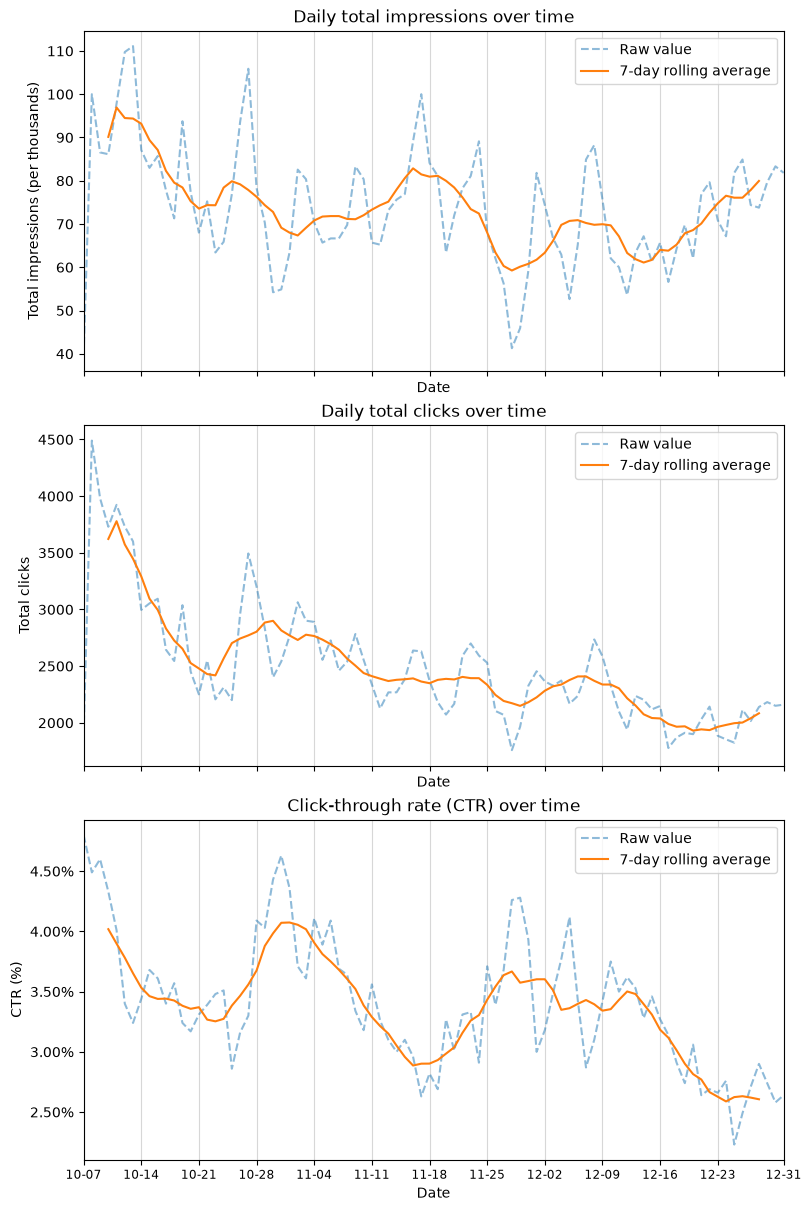

In [33]:
# [Presentation] Trend analysis
midFunnel_df = promo_df[["total_impressions", "total_clicks", "ctr"]].copy()
for col in midFunnel_df.columns:
  if col == "ctr":
    midFunnel_df = sma_rolling_mean(midFunnel_df, windows=[7], numerator="total_clicks", rate_mean=True, denominator="total_impressions", name=col)
  else:
    midFunnel_df = sma_rolling_mean(midFunnel_df, windows=[7], numerator=col)

fig, ax = plt.subplots(3,1, figsize=(8,12), sharex=True, layout="constrained")

ax[0].plot(midFunnel_df.index, midFunnel_df.total_impressions / 1000, label="Raw value", linestyle="--", alpha=0.5)
ax[0].plot(midFunnel_df.index, midFunnel_df.total_impressions_sma_7d / 1000, label="7-day rolling average")
ax[0].set(xlabel="Date", ylabel="Total impressions (per thousands)", title="Daily total impressions over time")
ax[0].legend()
ax[0].grid(alpha=0.5, axis="x")

ax[1].plot(midFunnel_df.index, midFunnel_df.total_clicks, label="Raw value", linestyle="--", alpha=0.5)
ax[1].plot(midFunnel_df.index, midFunnel_df.total_clicks_sma_7d, label="7-day rolling average")
ax[1].set(xlabel="Date", ylabel="Total clicks", title="Daily total clicks over time")
ax[1].legend()
ax[1].grid(alpha=0.5, axis="x")

ax[2].plot(midFunnel_df.index, midFunnel_df.ctr, label="Raw value", linestyle="--", alpha=0.5)
ax[2].plot(midFunnel_df.index, midFunnel_df.ctr_sma_7d, label="7-day rolling average")
ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[2].set(xlabel="Date", ylabel="CTR (%)", title="Click-through rate (CTR) over time")
ax[2].legend()
ax[2].grid(alpha=0.5, axis="x")

format_date_axis(ax[1], midFunnel_df.index, n_ticks=13)
format_date_axis(ax[2], midFunnel_df.index, n_ticks=13)
plt.show()

In [34]:
# Total clicks outliers
clicks_outliers = outlier_detector(promo_df, "total_clicks")
clicks_outliers.sort_values("total_clicks", ascending=False)

Mean used: 2490.2443
Standard deviation used: 533.9709


,ad_spend,cpm,ctr,paid_downloads,cpi,arpd,appd,total_downloads,trpd,tppd,total_impressions,total_clicks,nonpaid_downloads,cir,roas
date,,,,,,,,,,,,,,,
2025-10-08,90,0.90,0.0449,3123,0.029,0.083,0.054,4211,259.209,168.642,100000.000000,4490.000000,1088,0.695546,2.880100
2025-10-09,90,1.04,0.0460,2787,0.032,0.063,0.031,4861,175.581,86.397,86538.461538,3980.769231,2074,0.700116,1.950900
2025-10-11,90,0.92,0.0401,2583,0.035,0.081,0.046,4408,209.223,118.818,97826.086957,3922.826087,1825,0.658454,2.324700
2025-10-12,90,0.82,0.0340,2541,0.035,0.056,0.021,4401,142.296,53.361,109756.097561,3731.707317,1860,0.680922,1.581067
2025-10-10,87,1.01,0.0433,2500,0.035,0.067,0.032,4662,167.500,80.000,86138.613861,3729.801980,2162,0.670277,1.925287
2025-10-13,90,0.81,0.0324,2361,0.038,0.069,0.031,3684,162.909,73.191,111111.111111,3600.000000,1323,0.655833,1.810100


In [35]:
# Total clicks monthly means
print(f"Mean total clicks by month:")
print(f"October (since the 7th): {midFunnel_df.total_clicks["2025-10"].mean():.2f}")
print(f"November: {midFunnel_df.total_clicks["2025-11"].mean():.2f}")
print(f"December: {midFunnel_df.total_clicks["2025-12"].mean():.2f}")

Mean total clicks by month:
October (since the 7th): 2964.96
November: 2444.10
December: 2152.07


In [36]:
# [Presentation] Month-on-month CTR change
midFunnel_monthly = midFunnel_df[["total_impressions", "total_clicks"]].resample('MS').sum()
midFunnel_monthly["ctr"] = midFunnel_monthly["total_clicks"] / midFunnel_monthly["total_impressions"]

diff = midFunnel_monthly.diff()
pct_change = midFunnel_monthly.pct_change()

midFunnel_monthly = pd.merge(midFunnel_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
midFunnel_monthly = pd.merge(midFunnel_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pct_change"))

print(f"Average click-through rate by month changed by {100 * midFunnel_monthly.ctr_diff.sum() / midFunnel_monthly.loc["2025-10-01", "ctr"]:.2f}%.")
midFunnel_monthly

Average click-through rate by month changed by -17.35%.


,total_impressions,total_clicks,ctr,total_impressions_diff,total_clicks_diff,ctr_diff,total_impressions_pct_change,total_clicks_pct_change,ctr_pct_change
date,,,,,,,,,
2025-10-01,2.013412e+06,74124.005068,0.036815,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,2.156786e+06,73322.960388,0.033996,143373.558746,-801.044679,-0.002819,0.071209,-0.010807,-0.076564
2025-12-01,2.192522e+06,66714.043759,0.030428,35736.709356,-6608.916630,-0.003568,0.016569,-0.090134,-0.104965


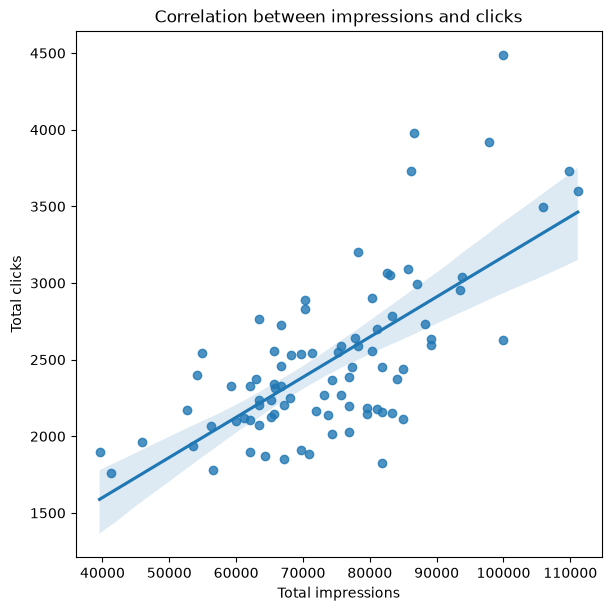

In [37]:
# Correlation analysis
fig, ax = plt.subplots(figsize=(6,6), layout="constrained")

sns.regplot(x=midFunnel_df.total_impressions, y=midFunnel_df.total_clicks)
ax.set(xlabel="Total impressions", ylabel="Total clicks", title="Correlation between impressions and clicks")

plt.show()

In [38]:
# Dissect impressions and clicks
results = []
pairs = [["total_impressions", "total_clicks"], ["total_impressions_sma_7d", "total_clicks_sma_7d"]]

for pair in pairs:
  f1 = pair[0]
  f2 = pair[1]
  r, p = stats.pearsonr(midFunnel_df[f1].dropna(), midFunnel_df[f2].dropna())
  results.append({"Feature 1": f1, "Feature 2": f2, "Correlation": r, "p-value": p})

midFunnel_corr_df = pd.DataFrame(results)

midFunnel_corr_df

,Feature 1,Feature 2,Correlation,p-value
0,total_impressions,total_clicks,0.686125,3.088674e-13
1,total_impressions_sma_7d,total_clicks_sma_7d,0.688226,1.739721e-12


##### Bottom of the funnel (BOFU): Clicks --CIR--> Install
The bottom part of the ad funnel is another key conversion: from clicks to downloads, which is key to the ad campaign.

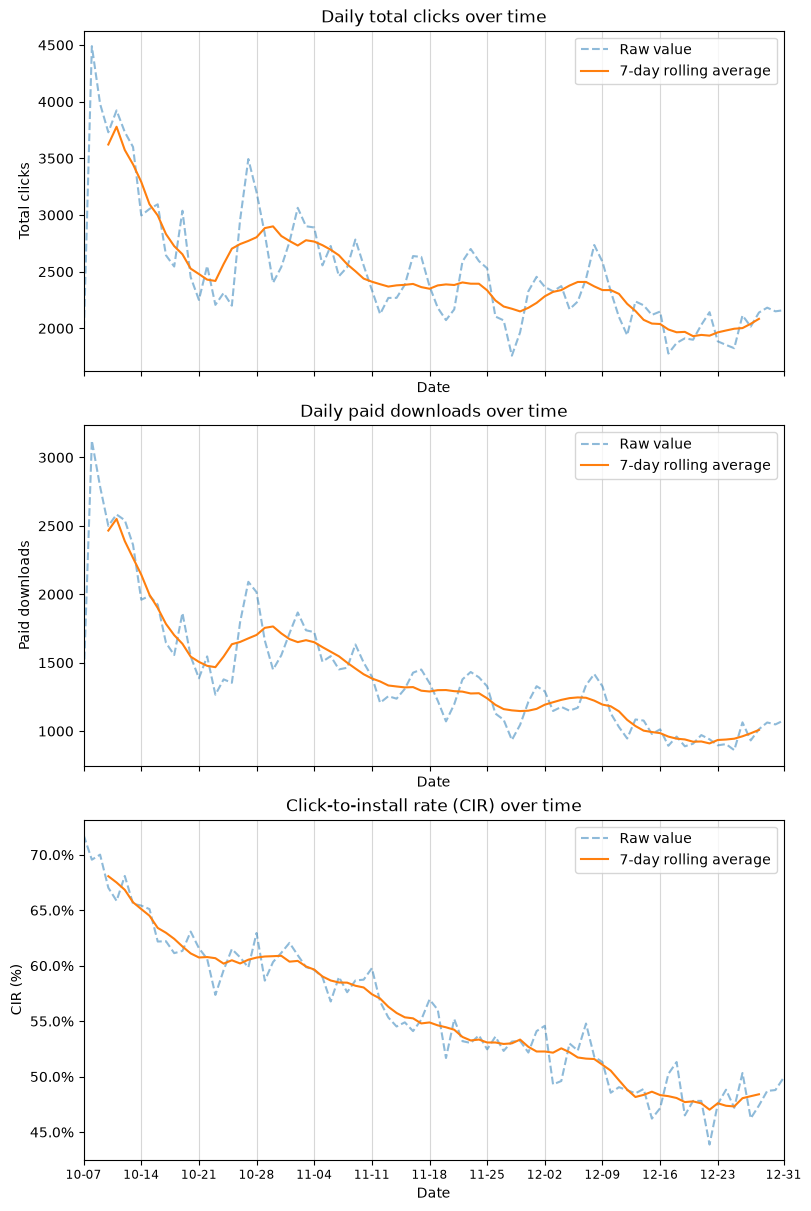

In [39]:
# Trend analysis
btmFunnel_df = promo_df[["total_clicks", "paid_downloads", "cir"]].copy()
for col in btmFunnel_df.columns:
  if col == "cir":
    btmFunnel_df = sma_rolling_mean(btmFunnel_df, windows=[7], numerator="paid_downloads", rate_mean=True, denominator="total_clicks", name=col)
  else:
    btmFunnel_df = sma_rolling_mean(btmFunnel_df, windows=[7], numerator=col)

fig, ax = plt.subplots(3,1, figsize=(8,12), sharex=True, layout="constrained")

ax[0].plot(btmFunnel_df.index, btmFunnel_df.total_clicks, label="Raw value", linestyle="--", alpha=0.5)
ax[0].plot(btmFunnel_df.index, btmFunnel_df.total_clicks_sma_7d, label="7-day rolling average")
ax[0].set(xlabel="Date", ylabel="Total clicks", title="Daily total clicks over time")
ax[0].legend()
ax[0].grid(alpha=0.5, axis="x")

ax[1].plot(btmFunnel_df.index, btmFunnel_df.paid_downloads, label="Raw value", linestyle="--", alpha=0.5)
ax[1].plot(btmFunnel_df.index, btmFunnel_df.paid_downloads_sma_7d, label="7-day rolling average")
ax[1].set(xlabel="Date", ylabel="Paid downloads", title="Daily paid downloads over time")
ax[1].legend()
ax[1].grid(alpha=0.5, axis="x")

ax[2].plot(btmFunnel_df.index, btmFunnel_df.cir, label="Raw value", linestyle="--", alpha=0.5)
ax[2].plot(btmFunnel_df.index, btmFunnel_df.cir_sma_7d, label="7-day rolling average")
ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[2].set(xlabel="Date", ylabel="CIR (%)", title="Click-to-install rate (CIR) over time")
ax[2].legend()
ax[2].grid(alpha=0.5, axis="x")

format_date_axis(ax[1], btmFunnel_df.index, n_ticks=13)
format_date_axis(ax[2], midFunnel_df.index, n_ticks=13)
plt.show()

In [40]:
# Paid download outliers
paidDownload_outliers = outlier_detector(promo_df, "paid_downloads")
paidDownload_outliers.sort_values("paid_downloads", ascending=False)

Mean used: 1412.3837
Standard deviation used: 457.0928


,ad_spend,cpm,ctr,paid_downloads,cpi,arpd,appd,total_downloads,trpd,tppd,total_impressions,total_clicks,nonpaid_downloads,cir,roas
date,,,,,,,,,,,,,,,
2025-10-08,90,0.90,0.0449,3123,0.029,0.083,0.054,4211,259.209,168.642,100000.000000,4490.000000,1088,0.695546,2.880100
2025-10-09,90,1.04,0.0460,2787,0.032,0.063,0.031,4861,175.581,86.397,86538.461538,3980.769231,2074,0.700116,1.950900
2025-10-11,90,0.92,0.0401,2583,0.035,0.081,0.046,4408,209.223,118.818,97826.086957,3922.826087,1825,0.658454,2.324700
2025-10-12,90,0.82,0.0340,2541,0.035,0.056,0.021,4401,142.296,53.361,109756.097561,3731.707317,1860,0.680922,1.581067
2025-10-10,87,1.01,0.0433,2500,0.035,0.067,0.032,4662,167.500,80.000,86138.613861,3729.801980,2162,0.670277,1.925287
2025-10-13,90,0.81,0.0324,2361,0.038,0.069,0.031,3684,162.909,73.191,111111.111111,3600.000000,1323,0.655833,1.810100


In [41]:
# Paid downloads monthly means
print(f"Mean paid downloads by month:")
print(f"October (since the 7th): {btmFunnel_df.paid_downloads["2025-10"].mean():.2f}")
print(f"November: {btmFunnel_df.paid_downloads["2025-11"].mean():.2f}")
print(f"December: {btmFunnel_df.paid_downloads["2025-12"].mean():.2f}")

Mean paid downloads by month:
October (since the 7th): 1889.44
November: 1373.47
December: 1065.32


In [42]:
# CIR monthly means
print(f"Mean click-to-install rate (CIR) by month:")
print(f"October (since the 7th): {btmFunnel_df.cir["2025-10"].mean():.2f}")
print(f"November: {btmFunnel_df.cir["2025-11"].mean():.2f}")
print(f"December: {btmFunnel_df.cir["2025-12"].mean():.2f}")

Mean click-to-install rate (CIR) by month:
October (since the 7th): 0.63
November: 0.56
December: 0.49


In [43]:
# [Presentation] Month-on-month CIR change
btmFunnel_monthly = btmFunnel_df[["total_clicks", "paid_downloads"]].resample('MS').sum()
btmFunnel_monthly["cir"] = btmFunnel_monthly["paid_downloads"] / btmFunnel_monthly["total_clicks"]

diff = btmFunnel_monthly.diff()
pct_change = btmFunnel_monthly.pct_change()

btmFunnel_monthly = pd.merge(btmFunnel_monthly, diff, left_index=True, right_index=True, suffixes=("", "_diff"))
btmFunnel_monthly = pd.merge(btmFunnel_monthly, pct_change, left_index=True, right_index=True, suffixes=("", "_pct_change"))

print(f"Average click-through rate by month changed by {100 * btmFunnel_monthly.cir_diff.sum() / btmFunnel_monthly.loc["2025-10-01", "cir"]:.2f}%.")
btmFunnel_monthly

Average click-through rate by month changed by -22.32%.


,total_clicks,paid_downloads,cir,total_clicks_diff,paid_downloads_diff,cir_diff,total_clicks_pct_change,paid_downloads_pct_change,cir_pct_change
date,,,,,,,,,
2025-10-01,74124.005068,47236,0.637256,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,73322.960388,41204,0.561952,-801.044679,-6032.0,-0.075304,-0.010807,-0.127699,-0.118169
2025-12-01,66714.043759,33025,0.495023,-6608.916630,-8179.0,-0.066929,-0.090134,-0.198500,-0.119101


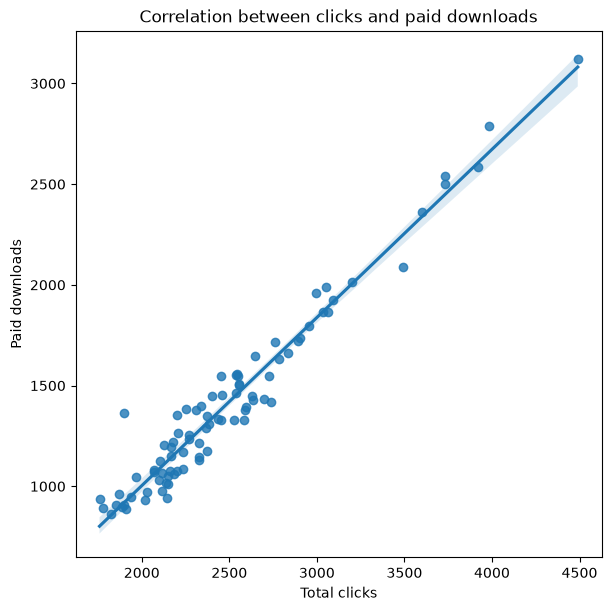

In [44]:
# Correlation analysis
fig, ax = plt.subplots(figsize=(6,6), layout="constrained")

sns.regplot(x=btmFunnel_df.total_clicks, y=btmFunnel_df.paid_downloads)
ax.set(xlabel="Total clicks", ylabel="Paid downloads", title="Correlation between clicks and paid downloads")

plt.show()

In [45]:
# Dissect impressions and clicks
results = []
pairs = [["total_clicks", "paid_downloads"], [ "total_clicks_sma_7d", "paid_downloads_sma_7d"]]

for pair in pairs:
  f1 = pair[0]
  f2 = pair[1]
  r, p = stats.pearsonr(btmFunnel_df[f1].dropna(), btmFunnel_df[f2].dropna())
  results.append({"Feature 1": f1, "Feature 2": f2, "Correlation": r, "p-value": p})

btmFunnel_corr_df = pd.DataFrame(results)

btmFunnel_corr_df

,Feature 1,Feature 2,Correlation,p-value
0,total_clicks,paid_downloads,0.975063,1.073632e-56
1,total_clicks_sma_7d,paid_downloads_sma_7d,0.992189,2.803580e-72


## 5. Additional analysis
In this section, I set out to investigate further the weekly pattern with seen in user engagement metrics, especailly most pronounced in impressions.

In [46]:
# Creating full adFunnel_df for further analysis
adFunnel_df = pd.merge(topFunnel_df, btmFunnel_df, left_index=True, right_index=True)
adFunnel_df = pd.merge(adFunnel_df, midFunnel_df[["ctr", "ctr_sma_7d"]], left_index=True, right_index=True)
adFunnel_df = pd.merge(adFunnel_df, promo_df[["cpi"]], left_index=True, right_index=True)

reorder_list = ["ad_spend", "total_impressions", "total_clicks", "paid_downloads", "cpm", "ctr", "cir", "cpi",
"ad_spend_sma_7d", "total_impressions_sma_7d", "total_clicks_sma_7d", "paid_downloads_sma_7d", "cpm_sma_7d", "ctr_sma_7d", "cir_sma_7d"]

adFunnel_df = adFunnel_df[reorder_list]

adFunnel_df

,ad_spend,total_impressions,total_clicks,paid_downloads,cpm,ctr,cir,cpi,ad_spend_sma_7d,total_impressions_sma_7d,total_clicks_sma_7d,paid_downloads_sma_7d,cpm_sma_7d,ctr_sma_7d,cir_sma_7d
date,,,,,,,,,,,,,,,
2025-10-07,36,39560.439560,1898.901099,1363,0.91,0.0480,0.717784,0.026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-08,90,100000.000000,4490.000000,3123,0.90,0.0449,0.695546,0.029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-09,90,86538.461538,3980.769231,2787,1.04,0.0460,0.700116,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-10,87,86138.613861,3729.801980,2500,1.01,0.0433,0.670277,0.035,81.857143,90132.972941,3622.000816,2465.428571,0.000908,0.040185,0.680681
2025-10-11,90,97826.086957,3922.826087,2583,0.92,0.0401,0.658454,0.035,88.285714,96923.877889,3778.747664,2550.714286,0.000911,0.038987,0.675016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,90,74380.165289,2015.702479,932,1.21,0.0271,0.462370,0.097,90.000000,77859.718489,2039.967910,984.000000,0.001156,0.026201,0.482361
2025-12-28,90,73770.491803,2139.344262,1014,1.22,0.0290,0.473977,0.089,90.000000,79953.147448,2083.720575,1008.714286,0.001126,0.026062,0.484093
2025-12-29,90,79646.017699,2182.300885,1063,1.13,0.0274,0.487101,0.085,NaN,NaN,NaN,NaN,NaN,NaN,NaN


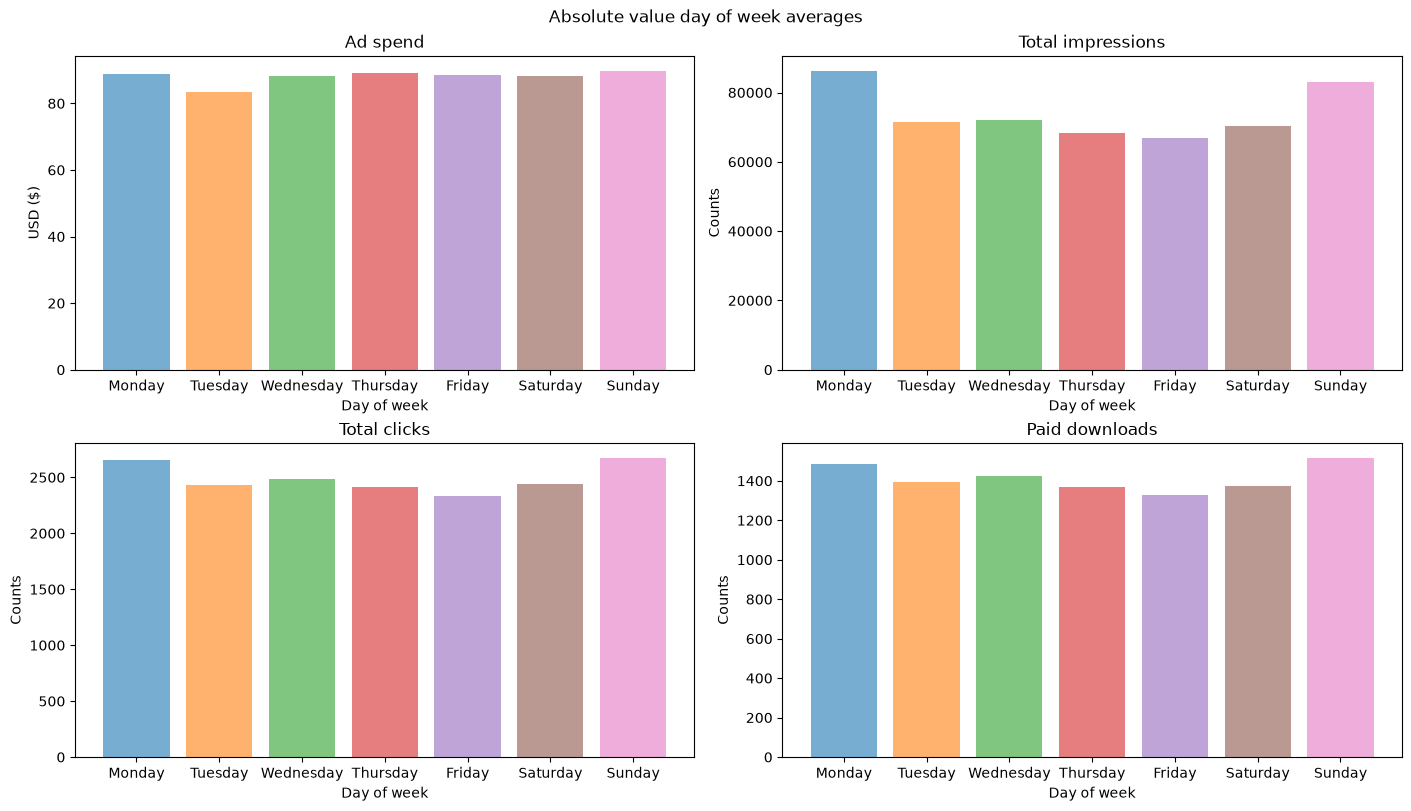

In [47]:
# [Presentation] Group by weekday: absolutes
df = adFunnel_df.copy()

absolute_cols = ["ad_spend", "total_impressions", "total_clicks", "paid_downloads"]
weekly_absolutes = df[absolute_cols].groupby(df.index.weekday).mean()
weekly_absolutes.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(2,2, figsize=(14,8), layout="constrained")

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

for i, a in enumerate(ax.flat):
  col = list(weekly_absolutes.columns)[i]
  col_label = col.replace("_", " ").capitalize()
  a.bar(x=weekly_absolutes.index, height=weekly_absolutes[col], color=colors, alpha=0.6)
  if col == "ad_spend":
    a.set_ylabel("USD ($)")
  else:
    a.set_ylabel("Counts")
  a.set(xlabel="Day of week", title=f"{col_label}")

plt.suptitle("Absolute value day of week averages")
plt.show()

In [ ]:
# [Presentation] Let's verify if total impressions' weekday differences are statistically significant
df = adFunnel_df[["total_impressions"]].copy()

groups = [g.values for _, g in df["total_impressions"].groupby(df.index.weekday)]
results = stats.tukey_hsd(*groups)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pvals = pd.DataFrame(results.pvalue, index=days, columns=days)

pvals[pvals < 0.05]

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Mon,NaN,NaN,NaN,0.013016,0.005419,0.045191,NaN
Tue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thu,0.013016,NaN,NaN,NaN,NaN,NaN,NaN
Fri,0.005419,NaN,NaN,NaN,NaN,NaN,0.036914
Sat,0.045191,NaN,NaN,NaN,NaN,NaN,NaN
Sun,NaN,NaN,NaN,NaN,0.036914,NaN,NaN


In [49]:
# Let's verify if total clicks' weekday differences are statistically significant
df = adFunnel_df[["total_clicks"]].copy()

groups = [g.values for _, g in df["total_clicks"].groupby(df.index.weekday)]
results = stats.tukey_hsd(*groups)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pvals = pd.DataFrame(results.pvalue, index=days, columns=days)

pvals[pvals < 0.05]

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Mon,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fri,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sat,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
# Let's verify if paid downloads' weekday differences are statistically significant
df = adFunnel_df[["paid_downloads"]].copy()

groups = [g.values for _, g in df["paid_downloads"].groupby(df.index.weekday)]
results = stats.tukey_hsd(*groups)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pvals = pd.DataFrame(results.pvalue, index=days, columns=days)

pvals[pvals < 0.05]

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Mon,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fri,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sat,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# End of analysis